# IRT with 1 item & 1 person: Latent Ability Estimation

- A student solves **the same item** (latent difficulty $\delta$) repeatedly, N=20 times. Correct = 1, wrong = 0.
- The latent ability of the student is $\theta$.
- The probability of a correct answer is (Rasch / 1PL IRT model)
  $$
  \phi = \text{logistic}(\theta - \delta) = \dfrac{1}{1+e^{-(\theta-\delta)}}  = \frac{e^\theta}{ e^\theta + e^\delta}
  $$  
- $Y_i \sim \text{Bernoulli}(\phi)$
- Question: What is the posterior probability of $\theta$ when a set of observations is provided?
  - Case 1 (2절): $\delta$ 의 참값을 아는 경우 (보정된 문항)
  - Case 2 (3절~): $\delta$ 도 모르는 경우 → 식별성 문제와 파라메터 drift (8절)
- Data are obtained by simulation. The true values $\theta_{\text{true}}$ and $\delta_{\text{true}}=0.7$ exist **only as simulation parameters**; the model does not know them.
- Discussion: the effect of the prior of $\theta$ on its posterior.
- Prediction: the number of correct answers when the student solves 10 new items.
- Stan/cmdstanpy & plots

## Table of Contents

1. 데이터와 문제 설정 (시뮬레이션)
2. δ의 참값을 아는 경우 (보정된 문항, calibrated item)
3. δ를 모르는 경우: Bayesian 모델과 식별성(identifiability)
4. Posterior 요약과 시각화
5. θ의 사전확률이 사후확률에 미치는 영향
6. 표본 수 N이 커지면? — 식별되는 것과 식별되지 않는 것
   - 6.1 N=20 vs N=200: 사후확률분포 비교
7. 사후예측: 새로운 문제 10개에서 맞추는 개수
8. 수치계산 안정성: θ − δ 와 파라메터 drift
   - 8.1 drift란 무엇인가
   - 8.2 실험: flat prior에서의 drift
   - 8.3 사전확률 선택으로 drift 방지하기
   - 8.4 drift 방지 방법 정리와 비교
   - 8.5 θ + δ = 0 제약은 언제 쓸 수 있는가
9. 결론 및 논의

## 1. 데이터와 문제 설정 (시뮬레이션)

시뮬레이션 파라메터로 학생의 잠재능력 $\theta_{\text{true}}$ 와 문항의 잠재난도 $\delta_{\text{true}} = 0.7$ 을 정하고,
$\phi_{\text{true}} = \text{logistic}(\theta_{\text{true}} - \delta_{\text{true}})$ 로 N=20개의 0/1 응답을 생성한다.

- 두 참값은 **시뮬레이션 파라메터로만 존재**한다. Stan 모델에는 관측값 $y$ 만 전달된다.
- 참값은 추정이 끝난 뒤 결과를 평가할 때에만 사용한다.
- 예외: 2절에서는 문항 난도가 사전 연구로 보정되어 **δ = 0.7 을 안다고 가정**하고, 이 값만 모델에 전달한다. θ의 참값은 여전히 모른다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from scipy.stats import norm, binom

SEED = 2026
rng = np.random.default_rng(SEED)

def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

# ----- 시뮬레이션 파라메터 (모델은 이 값들을 모른다) -----
THETA_TRUE = 1.2     # latent ability
DELTA_TRUE = 0.7     # latent difficulty
PHI_TRUE = logistic(THETA_TRUE - DELTA_TRUE)

N = 20
y = rng.binomial(n=1, p=PHI_TRUE, size=N).astype(int)

k = int(y.sum())
print("y =", y)
print(f"N={N}, success={k}, failure={N-k}, sample proportion={k/N:.3f}")

y = [1 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1]
N=20, success=11, failure=9, sample proportion=0.550


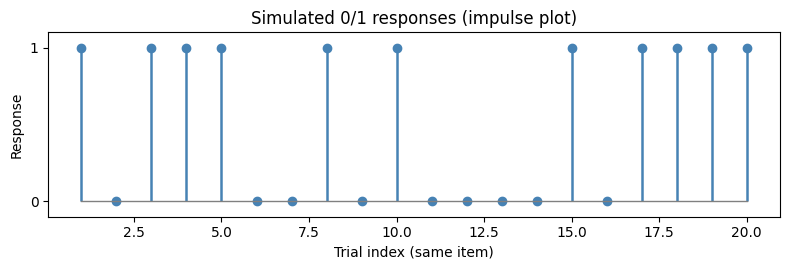

In [3]:
x = np.arange(1, N + 1)

plt.figure(figsize=(8, 2.8))
markerline, stemlines, baseline = plt.stem(x, y, linefmt="steelblue", markerfmt="o", basefmt="k-")
plt.setp(markerline, markerfacecolor="steelblue", markeredgecolor="steelblue")
plt.setp(stemlines, linewidth=1.8, color="steelblue")
plt.setp(baseline, linewidth=1.0, color="gray")

plt.yticks([0, 1])
plt.ylim(-0.1, 1.1)
plt.xlabel("Trial index (same item)")
plt.ylabel("Response")
plt.title("Simulated 0/1 responses (impulse plot)")
plt.tight_layout()
plt.show()

## 2. δ의 참값을 아는 경우 (보정된 문항, calibrated item)

상황: 이 문항은 이전에 많은 학생에게 출제되어 난도가 이미 정확히 추정(보정, calibration)되어 있다. 그래서 $\delta = 0.7$ 을 **알고 있다**.

모델에는 $\delta$ 를 파라메터가 아니라 **데이터**로 전달하고, 추정할 파라메터는 $\theta$ 하나뿐이다.

### 직관적 설명

- 데이터(20번의 정오답)가 직접 알려주는 것은 "이 학생이 이 문항을 맞출 확률" $\phi$, 즉 $\eta = \theta - \delta = \text{logit}(\phi)$ 이다.
- $\delta$ 를 알면 $\theta = \delta + \eta$ 이므로, $\eta$ 에 대한 정보가 **모두 θ에 대한 정보**가 된다. $\delta$ 가 척도의 기준점(anchor) 역할을 한다.
- 따라서 이 경우는 `bernoulli_logistic_estimation.ipynb` 의 1-파라메터 문제에 **이미 알고 있는 offset** $\delta$ 만 더해진 것과 같다.
- 데이터가 많아질수록 θ의 사후분포는 점점 좁아지고 참값으로 모인다 (δ를 모르는 3절 이후와 대조된다).

### 수학적 설명

$$
p(\theta \mid y, \delta) \;\propto\; \text{Normal}(\theta \mid \mu_\theta, \sigma_\theta)\;\prod_{i=1}^{N} \phi^{y_i}(1-\phi)^{1-y_i},
\qquad \phi = \text{logistic}(\theta - \delta)
$$

정규 근사(Laplace approximation)를 쓰면, Fisher information $I_N = N\hat\phi(1-\hat\phi)$ 과 $\hat\eta = \text{logit}(k/N)$ 에 대해

$$
\text{Var}(\theta \mid y) \approx \left(\frac{1}{\sigma_\theta^2} + I_N\right)^{-1},
\qquad
E[\theta \mid y] \approx \frac{\mu_\theta/\sigma_\theta^2 + I_N\,(\delta + \hat\eta)}{1/\sigma_\theta^2 + I_N}
$$

즉 사후평균은 prior 평균 $\mu_\theta$ 와 데이터가 말하는 값 $\delta + \hat\eta$ 의 **정밀도 가중평균**이다.

$N \to \infty$ 이면 $I_N \to \infty$ 이므로 $\text{sd}(\theta \mid y) \approx 1/\sqrt{I_N} \to 0$, $E[\theta\mid y] \to \delta + \text{logit}(\phi_{\text{true}}) = \theta_{\text{true}}$ (일치성, consistency).

아래에서는 prior $\theta \sim \text{Normal}(0, 1)$ 로 N=20 과 N=200 을 비교한다. N=200 데이터는 6.1절에서 쓰는 것과 같은 데이터다.

14:41:08 - cmdstanpy - INFO - compiling stan file D:\KOS-5101\intro-bayes\irt_1item_1person_known_delta.stan to exe file D:\KOS-5101\intro-bayes\irt_1item_1person_known_delta.exe
14:41:20 - cmdstanpy - INFO - compiled model executable: D:\KOS-5101\intro-bayes\irt_1item_1person_known_delta.exe
14:41:20 - cmdstanpy - INFO - CmdStan start processing
14:41:20 - cmdstanpy - INFO - Chain [1] start processing
14:41:20 - cmdstanpy - INFO - Chain [2] start processing
14:41:20 - cmdstanpy - INFO - Chain [3] start processing
14:41:20 - cmdstanpy - INFO - Chain [4] start processing
14:41:20 - cmdstanpy - INFO - Chain [3] done processing
14:41:20 - cmdstanpy - INFO - Chain [2] done processing
14:41:20 - cmdstanpy - INFO - Chain [1] done processing
14:41:20 - cmdstanpy - INFO - Chain [4] done processing
14:41:20 - cmdstanpy - INFO - CmdStan start processing
14:41:20 - cmdstanpy - INFO - Chain [1] start processing
14:41:20 - cmdstanpy - INFO - Chain [2] start processing
14:41:20 - cmdstanpy - INFO - 

δ known = 0.7,  prior θ ~ N(0, 1),  true θ = 1.2
case      k/N | E[θ] Stan E[θ] approx | sd Stan sd approx |          95% CrI  true inside?
N=20    0.550 |     0.750       0.749 |   0.415     0.410 | (-0.037,  1.588)  True
N=200   0.600 |     1.086       1.083 |   0.143     0.143 | ( 0.811,  1.372)  True


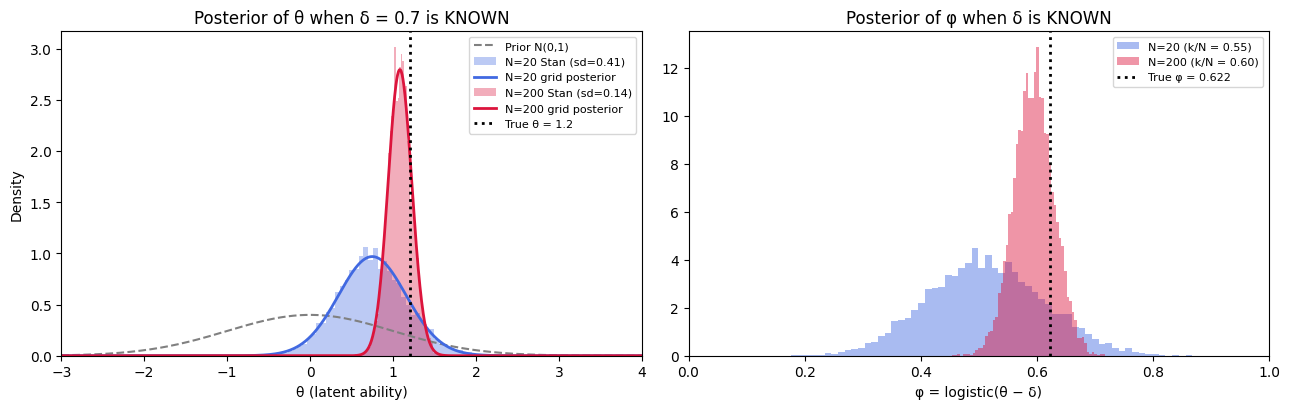

In [4]:
stan_known = """
data {
  int<lower=1> N;
  array[N] int<lower=0,upper=1> y;
  real delta;                 // KNOWN latent difficulty (calibrated item)
  real mu_theta;
  real<lower=0> sigma_theta;
}
parameters {
  real theta;                 // latent ability (the only unknown)
}
model {
  theta ~ normal(mu_theta, sigma_theta);
  y ~ bernoulli_logit(theta - delta);
}
generated quantities {
  real phi = inv_logit(theta - delta);
}
"""
with open("irt_1item_1person_known_delta.stan", "w", encoding="utf-8") as f:
    f.write(stan_known)
model_known = CmdStanModel(stan_file="irt_1item_1person_known_delta.stan")

def run_known(y_obs, mu_theta, sigma_theta, delta=DELTA_TRUE, seed=SEED):
    return model_known.sample(
        data={"N": len(y_obs), "y": list(map(int, y_obs)), "delta": delta,
              "mu_theta": mu_theta, "sigma_theta": sigma_theta},
        chains=4, parallel_chains=4, iter_warmup=1000, iter_sampling=2000,
        seed=seed, show_progress=False,
    )

MU_TH_K, SD_TH_K = 0.0, 1.0

# N=20 (same data as section 1) and N=200 (same data as section 6.1)
N_BIG = 200
y_200 = np.random.default_rng(SEED + 200).binomial(n=1, p=PHI_TRUE, size=N_BIG).astype(int)
known_cases = []
for name, y_obs in [("N=20", y), ("N=200", y_200)]:
    d = run_known(y_obs, MU_TH_K, SD_TH_K).draws_pd(vars=["theta", "phi"])
    known_cases.append((name, len(y_obs), int(np.sum(y_obs)), d))

print(f"δ known = {DELTA_TRUE},  prior θ ~ N({MU_TH_K:g}, {SD_TH_K:g}),  true θ = {THETA_TRUE}")
print(f"{'case':6s} {'k/N':>6s} | {'E[θ] Stan':>9s} {'E[θ] approx':>11s} | {'sd Stan':>7s} {'sd approx':>9s} | "
      f"{'95% CrI':>16s}  true inside?")
for name, n_, k_, d in known_cases:
    ph = k_ / n_
    I_N = n_ * ph * (1 - ph)
    var_ap = 1.0 / (1.0 / SD_TH_K**2 + I_N)
    mean_ap = var_ap * (MU_TH_K / SD_TH_K**2 + I_N * (DELTA_TRUE + np.log(ph / (1 - ph))))
    lo, hi = np.quantile(d["theta"], [0.025, 0.975])
    print(f"{name:6s} {ph:6.3f} | {d['theta'].mean():9.3f} {mean_ap:11.3f} | {d['theta'].std():7.3f} "
          f"{np.sqrt(var_ap):9.3f} | ({lo:6.3f}, {hi:6.3f})  {lo <= THETA_TRUE <= hi}")

# ---- plots: posterior of theta and phi, with grid posterior check ----
case_colors_k = {"N=20": "royalblue", "N=200": "crimson"}
g = np.linspace(-3, 5, 1601)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.plot(g, norm.pdf(g, MU_TH_K, SD_TH_K), color="gray", linestyle="--", linewidth=1.5, label="Prior N(0,1)")
for name, n_, k_, d in known_cases:
    col = case_colors_k[name]
    ax.hist(d["theta"], bins=60, density=True, alpha=0.35, color=col,
            label=f"{name} Stan (sd={d['theta'].std():.2f})")
    ph_g = logistic(g - DELTA_TRUE)
    lp = norm.logpdf(g, MU_TH_K, SD_TH_K) + k_ * np.log(ph_g) + (n_ - k_) * np.log1p(-ph_g)
    pg = np.exp(lp - lp.max()); pg /= np.trapezoid(pg, g)
    ax.plot(g, pg, color=col, linewidth=2, label=f"{name} grid posterior")
ax.axvline(THETA_TRUE, color="black", linestyle=":", linewidth=2, label=f"True θ = {THETA_TRUE}")
ax.set_xlim(-3, 4)
ax.set_xlabel("θ (latent ability)")
ax.set_ylabel("Density")
ax.set_title(f"Posterior of θ when δ = {DELTA_TRUE} is KNOWN")
ax.legend(fontsize=8)

ax = axes[1]
for name, n_, k_, d in known_cases:
    ax.hist(d["phi"], bins=60, density=True, alpha=0.45, color=case_colors_k[name],
            label=f"{name} (k/N = {k_/n_:.2f})")
ax.axvline(PHI_TRUE, color="black", linestyle=":", linewidth=2, label=f"True φ = {PHI_TRUE:.3f}")
ax.set_xlim(0, 1)
ax.set_xlabel("φ = logistic(θ − δ)")
ax.set_title("Posterior of φ when δ is KNOWN")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 결과 해석

**직관적으로:**
- δ를 알면 θ의 사후분포는 prior보다 뚜렷이 좁아지고, 데이터가 늘수록(N=200) 더 좁아지며 참값 근처로 모인다.
- N=20에서는 prior N(0,1) 쪽으로의 수축(shrinkage)과 표본 변동(k/N=0.55 < φ_true=0.62) 때문에 사후평균이 참값보다 낮다.
  N=200에서는 데이터의 비중이 커져서 prior의 영향이 작아진다.

**수학적으로:**
- 사후 sd는 $\big(1/\sigma_\theta^2 + N\hat\phi(1-\hat\phi)\big)^{-1/2}$ 로 잘 근사된다. N이 10배가 되면 information이 약 10배가 되므로 sd는 대략 $1/\sqrt{10}$ 배가 된다.
- Stan 결과, 정규 근사, grid posterior가 서로 일치한다.
- δ가 알려진 경우 $\eta$ 와 $\theta$ 는 상수 차이($\theta = \eta + \delta$)일 뿐이므로 $\theta$ 는 **식별된다(identified)**.

이제 3절부터는 δ도 모르는 경우를 다룬다. 이때는 같은 데이터로도 θ의 사후분포가 거의 좁아지지 않는다. 6절의 그림에서 두 경우를 직접 비교한다.

## 3. δ를 모르는 경우: Bayesian 모델과 식별성(identifiability)

모형:
- $Y_i \sim \text{Bernoulli}(\phi), \quad \phi = \text{logistic}(\theta - \delta)$
- $\theta \sim \text{Normal}(\mu_\theta, \sigma_\theta)$, 기본 설정 $\text{Normal}(0, 1)$
- $\delta \sim \text{Normal}(\mu_\delta, \sigma_\delta)$, 기본 설정 $\text{Normal}(0, 1)$

**식별성 문제.** likelihood는 $\theta$ 와 $\delta$ 를 **차이** $\eta = \theta - \delta$ 를 통해서만 본다.

$$
p(y \mid \theta, \delta) = \phi^{k}(1-\phi)^{N-k}, \qquad \phi = \text{logistic}(\theta - \delta)
$$

$(\theta, \delta)$ 와 $(\theta + c, \delta + c)$ 는 어떤 $c$ 에 대해서도 같은 likelihood를 준다.
따라서 1문항·1학생 데이터는 $\eta$ 에 대해서는 정보를 주지만, $\theta$ 와 $\delta$ 를 **따로** 구분할 정보는 주지 않는다.
이 구분은 오직 사전확률(prior)에 의해 이루어진다. 이것이 이 노트북의 핵심 주제다.

Stan 모델 설명:
- prior 파라메터를 `data` 로 받아 재컴파일 없이 여러 prior를 실험한다.
- `generated quantities` 에서 $\eta$, $\phi$ 와 두 종류의 예측값을 계산한다.
  - `k_same`: **같은 문항**을 10번 더 풀 때 맞추는 개수
  - `k_new`: **새로운 문항** 10개를 풀 때 맞추는 개수. 새 문항의 난도는 문항 모집단 $\delta_{\text{new}} \sim \text{Normal}(\mu_{\text{new}}, \sigma_{\text{new}})$ 에서 뽑는다.

In [5]:
stan_code = '''
data {
  int<lower=1> N;
  array[N] int<lower=0,upper=1> y;
  real mu_theta;              // prior of latent ability
  real<lower=0> sigma_theta;
  real mu_delta;              // prior of latent difficulty of the observed item
  real<lower=0> sigma_delta;
  int<lower=0> N_new;         // number of items for prediction
  real mu_new;                // population of new items' difficulty
  real<lower=0> sigma_new;
}
parameters {
  real theta;                 // latent ability
  real delta;                 // latent difficulty
}
model {
  theta ~ normal(mu_theta, sigma_theta);
  delta ~ normal(mu_delta, sigma_delta);
  y ~ bernoulli_logit(theta - delta);
}
generated quantities {
  real eta = theta - delta;
  real phi = inv_logit(eta);
  int k_same = binomial_rng(N_new, phi);     // same item, N_new more times
  int k_new = 0;                             // N_new new items
  for (j in 1:N_new) {
    real delta_new = normal_rng(mu_new, sigma_new);
    k_new += bernoulli_logit_rng(theta - delta_new);
  }
}
'''

with open("irt_1item_1person.stan", "w", encoding="utf-8") as f:
    f.write(stan_code)

model = CmdStanModel(stan_file="irt_1item_1person.stan")

N_NEW = 10
MU_NEW, SIGMA_NEW = 0.0, 1.0     # 새 문항 난도 모집단

def run(y_obs, mu_theta, sigma_theta, mu_delta, sigma_delta, seed=SEED):
    fit = model.sample(
        data={"N": len(y_obs), "y": list(map(int, y_obs)),
              "mu_theta": mu_theta, "sigma_theta": sigma_theta,
              "mu_delta": mu_delta, "sigma_delta": sigma_delta,
              "N_new": N_NEW, "mu_new": MU_NEW, "sigma_new": SIGMA_NEW},
        chains=4, parallel_chains=4, iter_warmup=1000, iter_sampling=2000,
        seed=seed, show_progress=False,
    )
    return fit

MU_TH, SD_TH = 0.0, 1.0
MU_DE, SD_DE = 0.0, 1.0
fit = run(y, MU_TH, SD_TH, MU_DE, SD_DE)

post = fit.draws_pd(vars=["theta", "delta", "eta", "phi", "k_same", "k_new"])
theta_s, delta_s = post["theta"].to_numpy(), post["delta"].to_numpy()
eta_s, phi_s = post["eta"].to_numpy(), post["phi"].to_numpy()
k_same_s, k_new_s = post["k_same"].to_numpy().astype(int), post["k_new"].to_numpy().astype(int)

summary = fit.summary()
candidate_cols = ["Mean", "mean", "SD", "sd", "StdDev", "5%", "50%", "95%", "N_Eff", "ESS_bulk", "R_hat"]
cols = list(dict.fromkeys(c for c in candidate_cols if c in summary.columns))
rows = [r for r in ["theta", "delta", "eta", "phi"] if r in summary.index]
print(summary.loc[rows, cols] if cols else summary.loc[rows])

14:41:21 - cmdstanpy - INFO - compiling stan file D:\KOS-5101\intro-bayes\irt_1item_1person.stan to exe file D:\KOS-5101\intro-bayes\irt_1item_1person.exe
14:41:33 - cmdstanpy - INFO - compiled model executable: D:\KOS-5101\intro-bayes\irt_1item_1person.exe
14:41:34 - cmdstanpy - INFO - CmdStan start processing
14:41:34 - cmdstanpy - INFO - Chain [1] start processing
14:41:34 - cmdstanpy - INFO - Chain [2] start processing
14:41:34 - cmdstanpy - INFO - Chain [3] start processing
14:41:34 - cmdstanpy - INFO - Chain [4] start processing
14:41:34 - cmdstanpy - INFO - Chain [3] done processing
14:41:34 - cmdstanpy - INFO - Chain [4] done processing
14:41:34 - cmdstanpy - INFO - Chain [2] done processing
14:41:34 - cmdstanpy - INFO - Chain [1] done processing


           Mean    StdDev        5%       50%       95%  ESS_bulk     R_hat
theta  0.069072  0.744742 -1.186060  0.084187  1.279720   2588.81  1.000580
delta -0.123425  0.743623 -1.342440 -0.121003  1.081250   2564.79  1.000400
eta    0.192497  0.438998 -0.527918  0.190401  0.920619   9308.47  0.999867
phi    0.545792  0.103979  0.371003  0.547457  0.715168   9308.47  0.999882


R_hat ≈ 1 이고 ESS가 충분하면 수렴한 것으로 본다. $\theta$ 와 $\delta$ 는 사후적으로 강하게 상관되어 있지만(아래 그림) 2차원 문제라 NUTS가 잘 처리한다.

## 4. Posterior 요약과 시각화

$\theta, \delta, \eta = \theta - \delta, \phi$ 의 사후분포를 prior와 함께 그린다. 이제 처음으로 참값과 비교한다.

In [6]:
def describe(name, s, true=None):
    lo, hi = np.quantile(s, [0.025, 0.975])
    t = "" if true is None else f" | true={true:.3f}, inside 95% CrI? {lo <= true <= hi}"
    print(f"{name:6s}: mean={s.mean():.3f}, sd={s.std():.3f}, 95% CrI=({lo:.3f}, {hi:.3f}){t}")

describe("theta", theta_s, THETA_TRUE)
describe("delta", delta_s, DELTA_TRUE)
describe("eta", eta_s, THETA_TRUE - DELTA_TRUE)
describe("phi", phi_s, PHI_TRUE)
print(f"\nposterior corr(theta, delta) = {np.corrcoef(theta_s, delta_s)[0, 1]:.3f}")
print(f"prior sd(theta) = {SD_TH:.3f}  ->  posterior sd(theta) = {theta_s.std():.3f}")
print(f"prior sd(eta)   = {np.hypot(SD_TH, SD_DE):.3f}  ->  posterior sd(eta)   = {eta_s.std():.3f}")

theta : mean=0.069, sd=0.745, 95% CrI=(-1.399, 1.499) | true=1.200, inside 95% CrI? True
delta : mean=-0.123, sd=0.744, 95% CrI=(-1.588, 1.313) | true=0.700, inside 95% CrI? True
eta   : mean=0.192, sd=0.439, 95% CrI=(-0.663, 1.058) | true=0.500, inside 95% CrI? True
phi   : mean=0.546, sd=0.104, 95% CrI=(0.340, 0.742) | true=0.622, inside 95% CrI? True

posterior corr(theta, delta) = 0.826
prior sd(theta) = 1.000  ->  posterior sd(theta) = 0.745
prior sd(eta)   = 1.414  ->  posterior sd(eta)   = 0.439


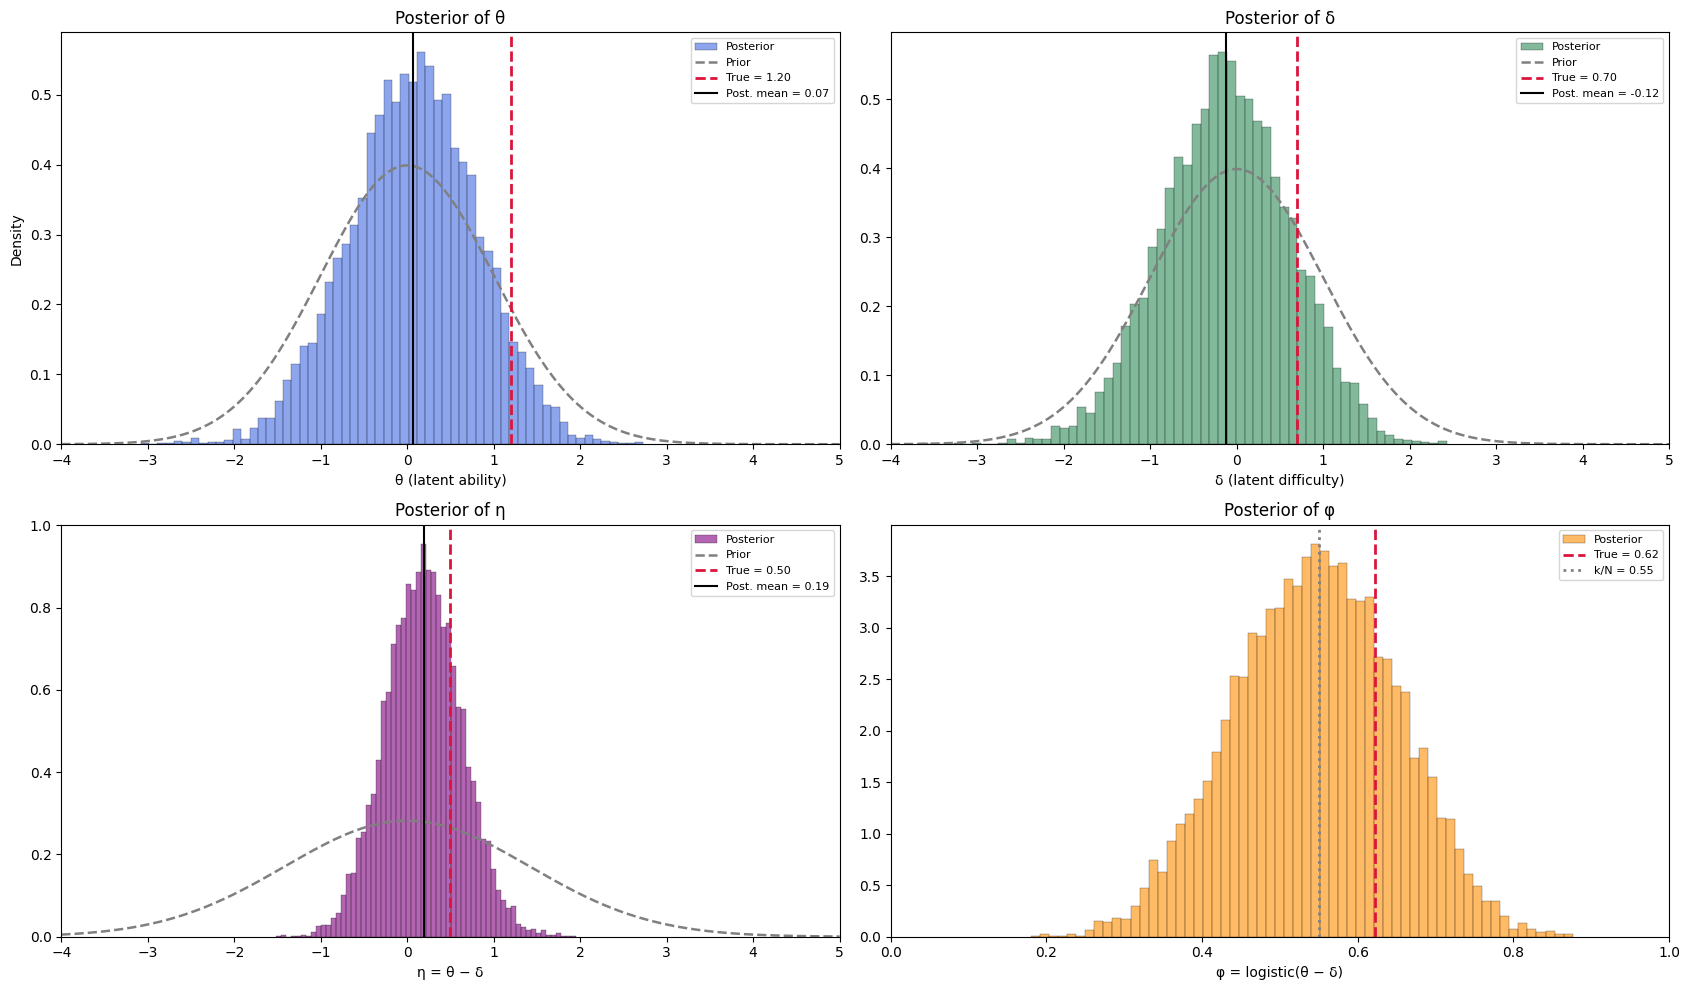

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(17, 10))

g = np.linspace(-4, 5, 500)
specs = [
    (axes[0, 0], theta_s, "θ (latent ability)", norm.pdf(g, MU_TH, SD_TH), g, THETA_TRUE, "royalblue"),
    (axes[0, 1], delta_s, "δ (latent difficulty)", norm.pdf(g, MU_DE, SD_DE), g, DELTA_TRUE, "seagreen"),
    (axes[1, 0], eta_s, "η = θ − δ", norm.pdf(g, MU_TH - MU_DE, np.hypot(SD_TH, SD_DE)), g,
     THETA_TRUE - DELTA_TRUE, "purple"),
]
for ax, s, lab, prior_pdf, grid, true, col in specs:
    ax.hist(s, bins=60, density=True, color=col, alpha=0.6, edgecolor="black", linewidth=0.3, label="Posterior")
    ax.plot(grid, prior_pdf, color="gray", linestyle="--", linewidth=1.8, label="Prior")
    ax.axvline(true, color="crimson", linestyle="--", linewidth=2, label=f"True = {true:.2f}")
    ax.axvline(s.mean(), color="black", linewidth=1.5, label=f"Post. mean = {s.mean():.2f}")
    ax.set_xlim(-4, 5)
    ax.set_xlabel(lab)
    ax.set_title(f"Posterior of {lab.split()[0]}")
    ax.legend(fontsize=8)
axes[0, 0].set_ylabel("Density")

ax = axes[1, 1]
ax.hist(phi_s, bins=60, density=True, color="darkorange", alpha=0.6, edgecolor="black", linewidth=0.3,
        label="Posterior")
ax.axvline(PHI_TRUE, color="crimson", linestyle="--", linewidth=2, label=f"True = {PHI_TRUE:.2f}")
ax.axvline(k / N, color="gray", linestyle=":", linewidth=2, label=f"k/N = {k/N:.2f}")
ax.set_xlim(0, 1)
ax.set_xlabel("φ = logistic(θ − δ)")
ax.set_title("Posterior of φ")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

관찰:
- $\eta$ 의 사후분포는 prior보다 확연히 좁아졌다 → 데이터가 $\eta$ 에 대해 정보를 준다.
- $\theta$ (그리고 $\delta$) 의 사후분포는 prior와 크게 다르지 않다 → 데이터가 $\theta$ 만을 따로 알려주지 못한다.

아래의 결합(joint) 사후분포를 보면 이유가 드러난다. 사후분포는 $\theta - \delta = \text{const}$ 방향(기울기 1인 직선)을 따라 길게 늘어진 능선(ridge) 모양이다.
능선 **위에서의 위치**는 데이터가 아니라 prior가 정한다. 비교를 위해 2차원 격자에서 직접 계산한 사후분포의 등고선도 겹쳐 그린다.

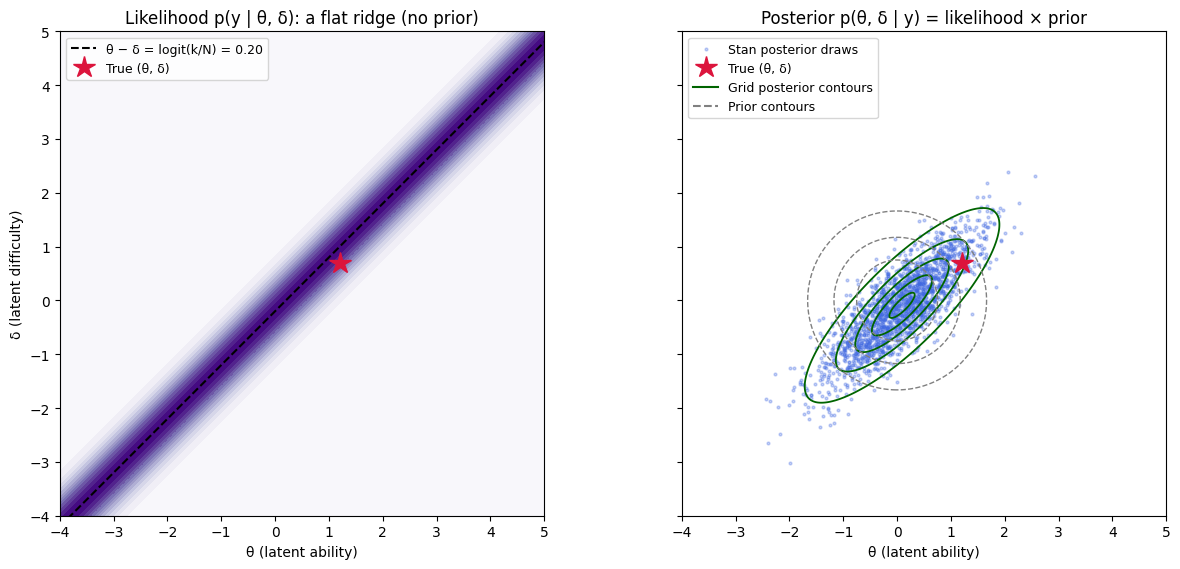

In [8]:
# 2D grid posterior (numerical check of Stan result)
tg = np.linspace(-4, 5, 301)
dg = np.linspace(-4, 5, 301)
TT, DD = np.meshgrid(tg, dg)
P = logistic(TT - DD)
log_post = (norm.logpdf(TT, MU_TH, SD_TH) + norm.logpdf(DD, MU_DE, SD_DE)
            + k * np.log(P) + (N - k) * np.log1p(-P))
post_grid = np.exp(log_post - log_post.max())

# likelihood only (no prior)
log_lik = k * np.log(P) + (N - k) * np.log1p(-P)
lik_grid = np.exp(log_lik - log_lik.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), sharex=True, sharey=True)

ax = axes[0]
cs = ax.contourf(TT, DD, lik_grid, levels=15, cmap="Purples")
eta_hat = np.log(k / (N - k)) if 0 < k < N else np.nan
ax.plot(tg, tg - eta_hat, color="black", linestyle="--", linewidth=1.5,
        label=f"θ − δ = logit(k/N) = {eta_hat:.2f}")
ax.plot(THETA_TRUE, DELTA_TRUE, "*", color="crimson", markersize=16, label="True (θ, δ)")
ax.set_title("Likelihood p(y | θ, δ): a flat ridge (no prior)")
ax.set_xlabel("θ (latent ability)")
ax.set_ylabel("δ (latent difficulty)")
ax.legend(fontsize=9, loc="upper left")

ax = axes[1]
idx = rng.choice(len(theta_s), size=2000, replace=False)
ax.scatter(theta_s[idx], delta_s[idx], s=4, alpha=0.3, color="royalblue", label="Stan posterior draws")
ax.contour(TT, DD, post_grid, levels=[0.05, 0.25, 0.5, 0.75, 0.95], colors="darkgreen", linewidths=1.3)
ax.contour(TT, DD, np.exp(norm.logpdf(TT, MU_TH, SD_TH) + norm.logpdf(DD, MU_DE, SD_DE)),
           levels=3, colors="gray", linestyles="--", linewidths=1)
ax.plot(THETA_TRUE, DELTA_TRUE, "*", color="crimson", markersize=16, label="True (θ, δ)")
ax.plot([], [], color="darkgreen", label="Grid posterior contours")
ax.plot([], [], color="gray", linestyle="--", label="Prior contours")
ax.set_title("Posterior p(θ, δ | y) = likelihood × prior")
ax.set_xlabel("θ (latent ability)")
ax.set_xlim(-4, 5)
ax.set_ylim(-4, 5)
ax.set_aspect("equal")
axes[0].set_aspect("equal")
ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

## 5. θ의 사전확률이 사후확률에 미치는 영향

같은 데이터에 대해 prior를 바꿔 가며 $\theta$ 의 사후분포를 비교한다.

| 실험 | θ prior | δ prior | 의미 |
|---|---|---|---|
| A | Normal(0, 1) | Normal(0, 1) | 기준 |
| B | Normal(0, 3) | Normal(0, 1) | θ에 대해 모호한(넓은) prior |
| C | Normal(2, 0.5) | Normal(0, 1) | "능력이 높다"는 강한 믿음 |
| D | Normal(−1, 0.5) | Normal(0, 1) | "능력이 낮다"는 강한 믿음 |
| E | Normal(0, 1) | Normal(0.7, 0.05) | 문항 난도가 사전 연구로 **보정(calibrated)** 되어 거의 알려진 경우 |

실험 E는 $\delta$ 를 이전 연구(많은 학생의 응답)로 이미 정확히 추정해 둔 상황을 흉내 낸 것이다.
이 경우에만 $\theta$ 가 사실상 식별된다.

14:41:35 - cmdstanpy - INFO - CmdStan start processing
14:41:35 - cmdstanpy - INFO - Chain [1] start processing
14:41:35 - cmdstanpy - INFO - Chain [2] start processing
14:41:35 - cmdstanpy - INFO - Chain [3] start processing
14:41:35 - cmdstanpy - INFO - Chain [4] start processing
14:41:35 - cmdstanpy - INFO - Chain [3] done processing
14:41:35 - cmdstanpy - INFO - Chain [1] done processing
14:41:35 - cmdstanpy - INFO - Chain [2] done processing
14:41:35 - cmdstanpy - INFO - Chain [4] done processing
14:41:35 - cmdstanpy - INFO - CmdStan start processing
14:41:35 - cmdstanpy - INFO - Chain [1] start processing
14:41:35 - cmdstanpy - INFO - Chain [2] start processing
14:41:35 - cmdstanpy - INFO - Chain [3] start processing
14:41:35 - cmdstanpy - INFO - Chain [4] start processing
14:41:35 - cmdstanpy - INFO - Chain [3] done processing
14:41:35 - cmdstanpy - INFO - Chain [1] done processing
14:41:35 - cmdstanpy - INFO - Chain [2] done processing
14:41:35 - cmdstanpy - INFO - Chain [4] do

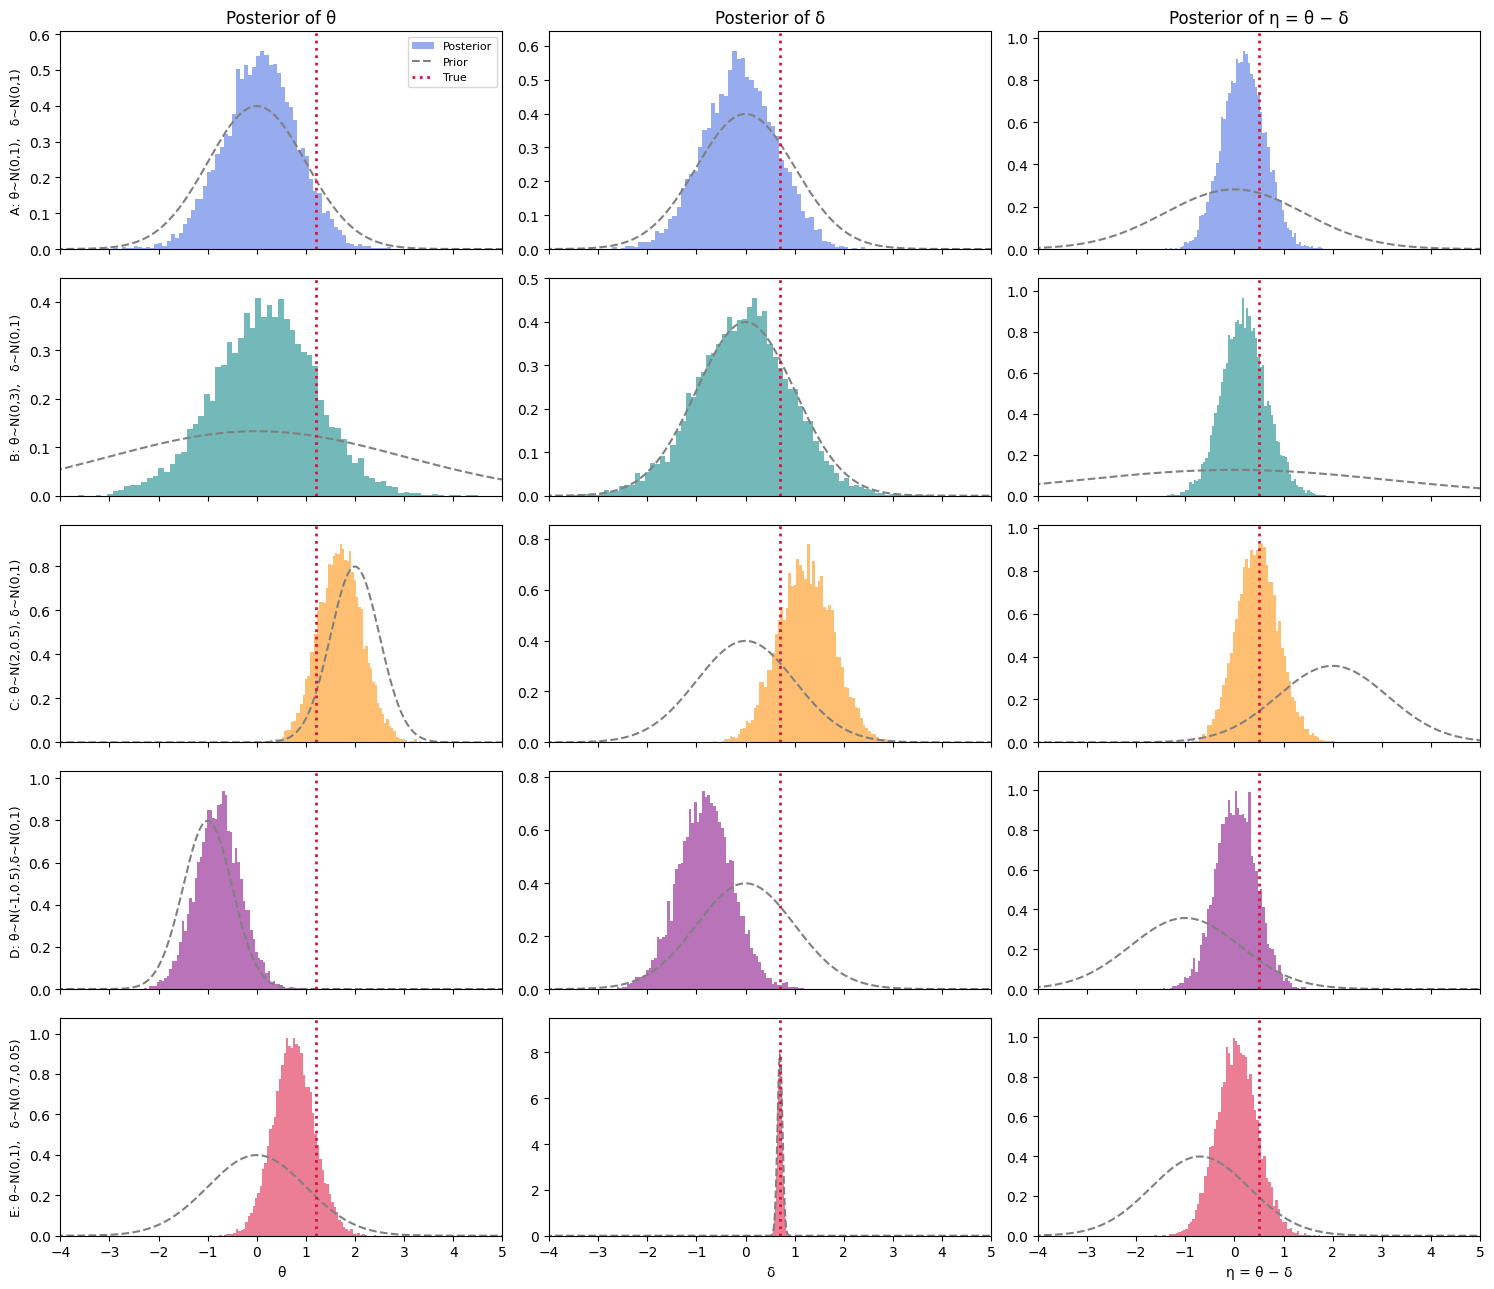

Observed: k=11/20.  True θ=1.2, δ=0.7, η=0.50
experiment                             prior θ post θ mean post θ sd sd ratio post η mean post η sd
A: θ~N(0,1),   δ~N(0,1)                 N(0,1)       0.069     0.745     0.74       0.192     0.439
B: θ~N(0,3),   δ~N(0,1)                 N(0,3)       0.164     1.042     0.35       0.203     0.453
C: θ~N(2,0.5), δ~N(0,1)               N(2,0.5)       1.698     0.448     0.90       0.471     0.433
D: θ~N(-1,0.5),δ~N(0,1)              N(-1,0.5)      -0.787     0.456     0.91       0.033     0.414
E: θ~N(0,1),   δ~N(0.7,0.05)            N(0,1)       0.751     0.420     0.42       0.053     0.417


In [9]:
experiments = [
    ("A: θ~N(0,1),   δ~N(0,1)",    0.0, 1.0, 0.0, 1.0),
    ("B: θ~N(0,3),   δ~N(0,1)",    0.0, 3.0, 0.0, 1.0),
    ("C: θ~N(2,0.5), δ~N(0,1)",    2.0, 0.5, 0.0, 1.0),
    ("D: θ~N(-1,0.5),δ~N(0,1)",   -1.0, 0.5, 0.0, 1.0),
    ("E: θ~N(0,1),   δ~N(0.7,0.05)", 0.0, 1.0, 0.7, 0.05),
]
colors = ["royalblue", "teal", "darkorange", "purple", "crimson"]

exp_results = []
for name, mt, st, mdl, sdl in experiments:
    f = run(y, mt, st, mdl, sdl)
    d = f.draws_pd(vars=["theta", "delta", "eta", "phi", "k_same", "k_new"])
    exp_results.append((name, mt, st, mdl, sdl, d))

g = np.linspace(-5, 6, 600)
fig, axes = plt.subplots(len(exp_results), 3, figsize=(15, 2.6 * len(exp_results)), sharex="col")
for i, ((name, mt, st, mdl, sdl, d), col) in enumerate(zip(exp_results, colors)):
    for j, (var, pm, ps, true, lab) in enumerate([
        ("theta", mt, st, THETA_TRUE, "θ"),
        ("delta", mdl, sdl, DELTA_TRUE, "δ"),
        ("eta", mt - mdl, np.hypot(st, sdl), THETA_TRUE - DELTA_TRUE, "η = θ − δ"),
    ]):
        ax = axes[i, j]
        ax.hist(d[var], bins=70, density=True, color=col, alpha=0.55, label="Posterior")
        prior_pdf = norm.pdf(g, pm, ps)
        ax.plot(g, prior_pdf, color="gray", linestyle="--", linewidth=1.5, label="Prior")
        ax.axvline(true, color="crimson", linestyle=":", linewidth=2, label="True")
        ax.set_xlim(-4, 5)
        # keep very narrow priors (E: delta) from flattening the panel
        ax.set_ylim(0, max(np.histogram(d[var], bins=70, density=True)[0].max(), min(prior_pdf.max(), 3)) * 1.1)
        if i == 0:
            ax.set_title(f"Posterior of {lab}")
        if j == 0:
            ax.set_ylabel(name, fontsize=9)
        if i == len(exp_results) - 1:
            ax.set_xlabel(lab)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Observed: k={k}/{N}.  True θ={THETA_TRUE}, δ={DELTA_TRUE}, η={THETA_TRUE-DELTA_TRUE:.2f}")
print(f"{'experiment':32s} {'prior θ':>13s} {'post θ mean':>11s} {'post θ sd':>9s} {'sd ratio':>8s} "
      f"{'post η mean':>11s} {'post η sd':>9s}")
for name, mt, st, mdl, sdl, d in exp_results:
    th, et = d["theta"].to_numpy(), d["eta"].to_numpy()
    print(f"{name:32s} {f'N({mt:g},{st:g})':>13s} {th.mean():11.3f} {th.std():9.3f} {th.std()/st:8.2f} "
          f"{et.mean():11.3f} {et.std():9.3f}")

### 해석: θ의 prior가 posterior에 미치는 영향

1. **η 는 prior에 거의 둔감하다.** 모든 실험에서 $\eta = \theta - \delta$ 의 사후분포는 비슷하다 (logit(k/N) 근처). 데이터가 직접 정보를 주는 양이기 때문이다.
   (단 η의 prior 평균 $\mu_\theta-\mu_\delta$ 가 0에서 멀어지는 C, D, E에서는 η 사후분포도 그 방향으로 약간 끌려간다. N=20은 작은 표본이다.)

2. **θ 는 prior에 매우 민감하다.** 데이터는 "θ가 δ보다 얼마나 큰가"만 알려준다.
   - A (θ, δ prior 폭이 같음): 데이터의 정보가 θ와 δ에 **반씩** 나뉜다. posterior sd(θ)는 prior sd의 약 0.7~0.8배로 조금만 줄어든다.
   - B (θ prior가 넓음): 정보의 대부분이 θ로 간다. 정규 근사로 보면 θ 쪽 몫은 $\sigma_\theta^2 / (\sigma_\theta^2 + \sigma_\delta^2) = 9/10$ 이다.
     그러나 δ의 불확실성(sd=1)이 그대로 θ로 옮겨 와 posterior sd(θ)는 약 1 수준에 머문다 (prior sd 3에 비하면 크게 줄었지만 δ의 prior sd 아래로는 내려가지 못한다).
   - C, D (강한 θ prior): posterior θ는 prior 평균 근처에 머문다. 데이터와의 불일치는 주로 δ가 흡수한다 (C에서는 δ 사후분포가 커지고, D에서는 작아진다).
     참값 θ=1.2 와 비교하면 C는 과대, D는 과소 추정이다. **데이터로는 이 오류를 교정할 수 없다.**
   - E (δ가 보정됨): δ가 사실상 고정되므로 η의 정보가 전부 θ로 간다. θ의 사후 sd가 prior의 약 0.4배로 뚜렷이 줄어들고 사후 평균이 참값 쪽으로 크게 이동한다.
     이는 1문항 모델에서 **θ에 대해 진짜로 학습이 일어나는 유일한 경우**다. 남은 차이는 θ prior N(0,1)에 의한 수축과 N=20의 표본 변동 때문이다.

3. **요점.** 1문항·1학생 설계에서 θ의 사후분포는 "데이터 + θ prior + δ prior" 의 합작품이며, θ와 δ의 분리는 **전적으로 prior가 결정**한다.
   θ를 의미 있게 추정하려면 (i) 문항 난도를 미리 보정하거나(E), (ii) 여러 문항과 여러 학생을 함께 관측해 척도를 고정해야 한다 (다문항 IRT; 보통 $\text{mean}(\delta)=0$ 또는 $\theta \sim N(0,1)$ 로 척도를 정함).

## 6. 표본 수 N이 커지면? — 식별되는 것과 식별되지 않는 것

같은 문항을 N=20, 100, 500, 2000번 푼다고 하자 (기준 prior A).
보통의 추정 문제라면 N이 커질수록 사후 sd가 0으로 줄지만, 여기서는
- $\eta$ 의 사후 sd는 $\approx 1/\sqrt{N}$ 속도로 줄어든다.
- $\theta$ 의 사후 sd는 0이 아닌 값에서 멈춘다. 정규 근사에서 그 한계는

$$
\text{sd}(\theta \mid \eta \text{ known}) = \sqrt{\frac{\sigma_\theta^2\,\sigma_\delta^2}{\sigma_\theta^2 + \sigma_\delta^2}} = \sqrt{1/2} \approx 0.707
$$

즉 **데이터를 아무리 많이 모아도 θ는 prior가 허용하는 이상으로 정확해지지 않는다.**

비교를 위해 아래의 sd 그림에는 **δ를 아는 경우(2절)** 의 θ 사후 sd도 함께 그린다. δ를 알면 θ의 사후 sd는 η와 마찬가지로 $\approx 1/\sqrt{N}$ 속도로 줄어든다.

14:41:38 - cmdstanpy - INFO - CmdStan start processing
14:41:38 - cmdstanpy - INFO - Chain [1] start processing
14:41:38 - cmdstanpy - INFO - Chain [2] start processing
14:41:38 - cmdstanpy - INFO - Chain [3] start processing
14:41:38 - cmdstanpy - INFO - Chain [4] start processing
14:41:38 - cmdstanpy - INFO - Chain [1] done processing
14:41:38 - cmdstanpy - INFO - Chain [3] done processing
14:41:38 - cmdstanpy - INFO - Chain [4] done processing
14:41:38 - cmdstanpy - INFO - Chain [2] done processing
14:41:38 - cmdstanpy - INFO - CmdStan start processing
14:41:38 - cmdstanpy - INFO - Chain [1] start processing
14:41:38 - cmdstanpy - INFO - Chain [2] start processing
14:41:38 - cmdstanpy - INFO - Chain [3] start processing
14:41:38 - cmdstanpy - INFO - Chain [4] start processing
14:41:38 - cmdstanpy - INFO - Chain [4] done processing
14:41:38 - cmdstanpy - INFO - Chain [3] done processing
14:41:38 - cmdstanpy - INFO - Chain [2] done processing
14:41:38 - cmdstanpy - INFO - Chain [1] do

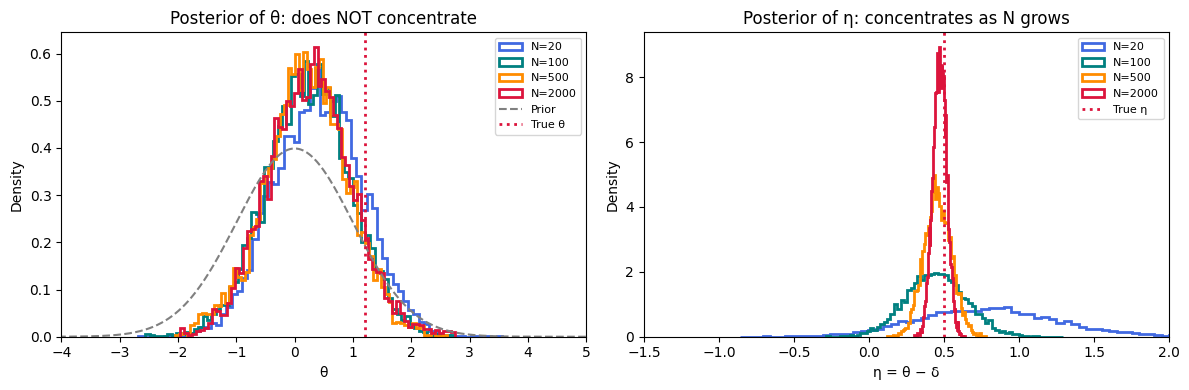

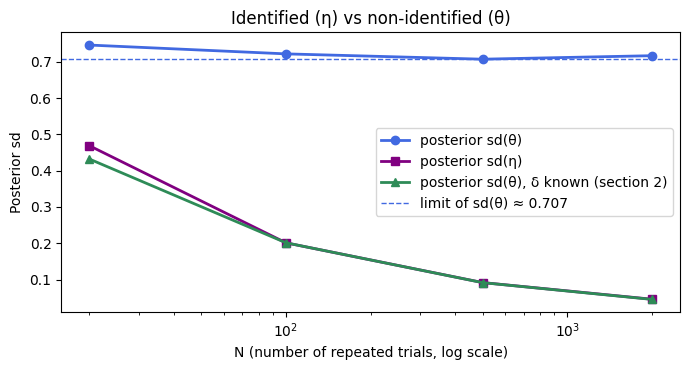

In [10]:
N_list = [20, 100, 500, 2000]
rng_n = np.random.default_rng(SEED + 1)
sd_theta, sd_eta, sd_theta_known = [], [], []
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for n_i, col in zip(N_list, ["royalblue", "teal", "darkorange", "crimson"]):
    y_i = rng_n.binomial(1, PHI_TRUE, size=n_i)
    d = run(y_i, MU_TH, SD_TH, MU_DE, SD_DE).draws_pd(vars=["theta", "eta"])
    sd_theta.append(d["theta"].std())
    sd_eta.append(d["eta"].std())
    sd_theta_known.append(run_known(y_i, MU_TH_K, SD_TH_K).draws_pd(vars=["theta"])["theta"].std())
    axes[0].hist(d["theta"], bins=70, density=True, histtype="step", linewidth=2, color=col, label=f"N={n_i}")
    axes[1].hist(d["eta"], bins=70, density=True, histtype="step", linewidth=2, color=col, label=f"N={n_i}")

axes[0].plot(g, norm.pdf(g, MU_TH, SD_TH), color="gray", linestyle="--", label="Prior")
axes[0].axvline(THETA_TRUE, color="crimson", linestyle=":", linewidth=2, label="True θ")
axes[1].axvline(THETA_TRUE - DELTA_TRUE, color="crimson", linestyle=":", linewidth=2, label="True η")
axes[0].set_xlim(-4, 5); axes[1].set_xlim(-1.5, 2)
axes[0].set_xlabel("θ"); axes[1].set_xlabel("η = θ − δ")
axes[0].set_title("Posterior of θ: does NOT concentrate")
axes[1].set_title("Posterior of η: concentrates as N grows")
for ax in axes:
    ax.set_ylabel("Density"); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(N_list, sd_theta, "o-", color="royalblue", linewidth=2, label="posterior sd(θ)")
ax.plot(N_list, sd_eta, "s-", color="purple", linewidth=2, label="posterior sd(η)")
ax.plot(N_list, sd_theta_known, "^-", color="seagreen", linewidth=2, label="posterior sd(θ), δ known (section 2)")
ax.axhline(np.sqrt(SD_TH**2 * SD_DE**2 / (SD_TH**2 + SD_DE**2)), color="royalblue", linestyle="--",
           linewidth=1, label="limit of sd(θ) ≈ 0.707")
ax.set_xscale("log")
ax.set_xlabel("N (number of repeated trials, log scale)")
ax.set_ylabel("Posterior sd")
ax.set_title("Identified (η) vs non-identified (θ)")
ax.legend()
plt.tight_layout()
plt.show()

## 6.1 N=20 vs N=200: 사후확률분포 비교

같은 학생이 같은 문항을 **200번** 푼 경우와 앞의 20번 푼 경우의 사후분포를 나란히 비교한다 (prior는 기준 A: $\theta, \delta \sim \text{Normal}(0,1)$).

### 직관적 설명

- 데이터가 10배 많아지면 "이 학생이 **이 문항**을 맞출 확률" $\phi$ 는 훨씬 정확히 알게 된다. 따라서 $\eta = \theta - \delta = \text{logit}(\phi)$ 의 사후분포는 뚜렷이 좁아진다.
- 하지만 "정답률이 62%"라는 사실은 "능력 1.2 · 난도 0.7"로도, "능력 0.5 · 난도 0.0"으로도, "능력 2.0 · 난도 1.5"로도 똑같이 설명된다.
  데이터를 아무리 모아도 이 셋을 구분할 수 없다.
- 그래서 $(\theta, \delta)$ 평면의 사후분포는 기울기 1인 능선을 따라 **폭만 얇아지고 길이는 그대로**다.
  능선의 길이 방향은 prior가 정하므로, $\theta$ 와 $\delta$ 각각의 사후분포는 거의 변하지 않는다.

### 수학적 설명

정규 근사(Laplace approximation)를 쓰면 $\eta$ 에 대한 likelihood는 대략

$$
p(y \mid \eta) \approx \text{Normal}\!\left(\hat\eta,\ \frac{1}{N\hat\phi(1-\hat\phi)}\right), \qquad \hat\eta = \text{logit}(k/N)
$$

이다. $N\phi(1-\phi)$ 는 Fisher information이며 $N$ 에 비례한다. prior에서 $\eta \sim \text{Normal}(\mu_\theta - \mu_\delta,\ \sigma_\theta^2 + \sigma_\delta^2)$ 이므로

$$
\text{Var}(\eta \mid y) \approx s_\eta^2 = \left(\frac{1}{\sigma_\theta^2 + \sigma_\delta^2} + N\hat\phi(1-\hat\phi)\right)^{-1} \xrightarrow{N\to\infty} 0 .
$$

한편 $(\theta, \eta)$ 는 prior에서 결합정규분포이고, 데이터는 $\eta$ 를 통해서만 들어오므로 $p(\theta \mid \eta, y) = p(\theta \mid \eta)$ 이다. 정규분포의 조건부 공식으로

$$
\theta \mid \eta \sim \text{Normal}\!\left(\mu_\theta + w\,\big(\eta - (\mu_\theta - \mu_\delta)\big),\ \ \frac{\sigma_\theta^2 \sigma_\delta^2}{\sigma_\theta^2 + \sigma_\delta^2}\right),
\qquad w = \frac{\sigma_\theta^2}{\sigma_\theta^2 + \sigma_\delta^2}
$$

이고, 전분산 공식(law of total variance)에 의해

$$
\text{Var}(\theta \mid y) \approx \underbrace{\frac{\sigma_\theta^2 \sigma_\delta^2}{\sigma_\theta^2 + \sigma_\delta^2}}_{\text{N과 무관 (prior가 결정)}} + \underbrace{w^2\, s_\eta^2}_{\text{N이 커지면 } \to 0} .
$$

기준 prior ($\sigma_\theta = \sigma_\delta = 1$, $w = 1/2$) 에서는 $\text{Var}(\theta \mid y) \approx 0.5 + 0.25\, s_\eta^2$ 이다.
N=20일 때 $s_\eta^2 \approx 0.18$, N=200일 때 $s_\eta^2 \approx 0.02$ 이므로 $\text{sd}(\theta \mid y)$ 는 약 $0.74 \to 0.71$ 로 **거의 줄지 않는다.**
반면 $\text{sd}(\eta \mid y)$ 는 약 $0.43 \to 0.14$ 로 $\sqrt{10} \approx 3.2$ 배 가까이 줄어든다.
또한 사후평균은 $E[\theta \mid y] \approx \mu_\theta + w\,(E[\eta \mid y] - (\mu_\theta-\mu_\delta))$, 즉 $\eta$ 의 추정값의 **절반만** θ로 간다.

아래 코드는 이 근사식의 값과 Stan 결과를 함께 출력한다.

14:41:46 - cmdstanpy - INFO - CmdStan start processing
14:41:46 - cmdstanpy - INFO - Chain [1] start processing
14:41:46 - cmdstanpy - INFO - Chain [2] start processing
14:41:46 - cmdstanpy - INFO - Chain [3] start processing
14:41:46 - cmdstanpy - INFO - Chain [4] start processing
14:41:46 - cmdstanpy - INFO - Chain [1] done processing
14:41:46 - cmdstanpy - INFO - Chain [3] done processing
14:41:46 - cmdstanpy - INFO - Chain [4] done processing
14:41:46 - cmdstanpy - INFO - Chain [2] done processing


case      k/N | sd(η) approx sd(η) Stan | sd(θ) approx sd(θ) Stan | E[θ] approx E[θ] Stan
N=20    0.550 |        0.428      0.439 |        0.739      0.745 |       0.096     0.069
N=200   0.600 |        0.144      0.145 |        0.711      0.720 |       0.200     0.232

limit of sd(θ) as N→∞ : 0.707
true values           : θ=1.2, δ=0.7, η=0.50, φ=0.622


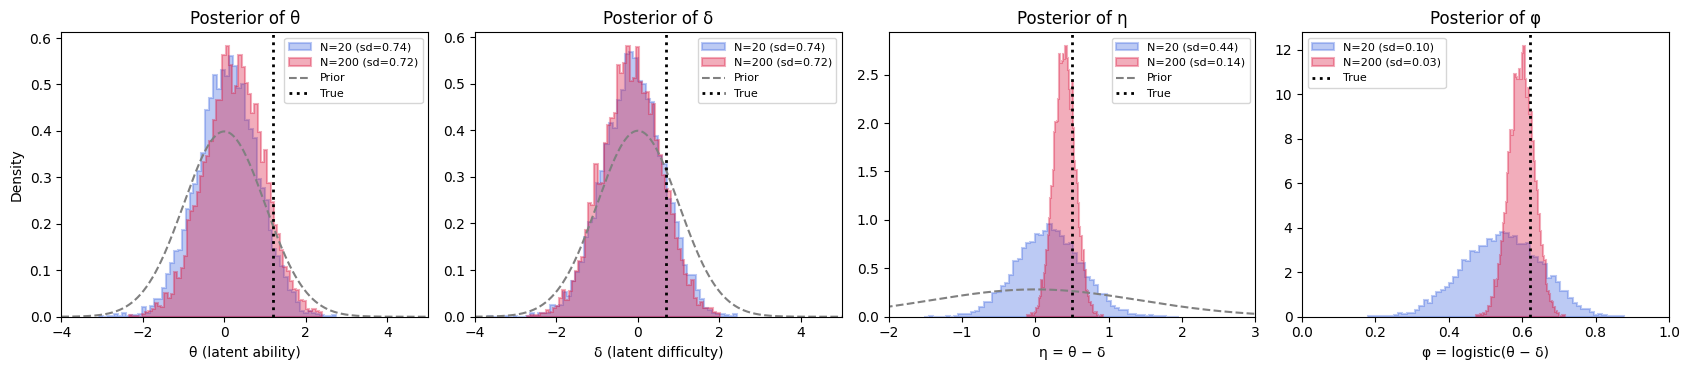

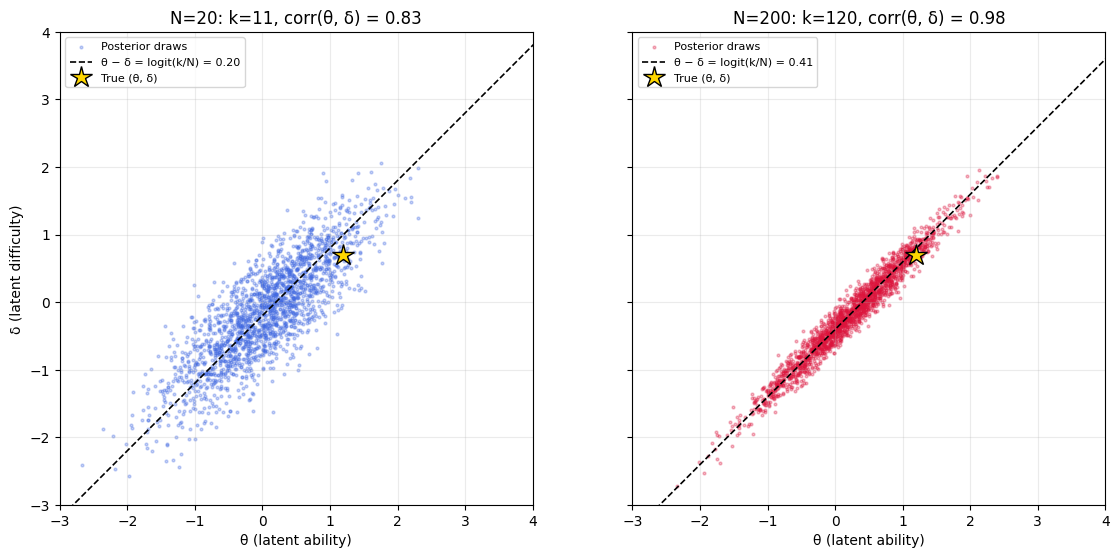

In [11]:
N_BIG = 200
rng_200 = np.random.default_rng(SEED + 200)           # 2절과 같은 N=200 데이터 (기존 rng 흐름과 분리)
y_200 = rng_200.binomial(n=1, p=PHI_TRUE, size=N_BIG).astype(int)
k_200 = int(y_200.sum())

fit_200 = run(y_200, MU_TH, SD_TH, MU_DE, SD_DE)
post_200 = fit_200.draws_pd(vars=["theta", "delta", "eta", "phi"])

cases = [("N=20", N, k, post), ("N=200", N_BIG, k_200, post_200)]

# ---- Normal (Laplace) approximation vs Stan ----
w = SD_TH**2 / (SD_TH**2 + SD_DE**2)
var_floor = SD_TH**2 * SD_DE**2 / (SD_TH**2 + SD_DE**2)
print(f"{'case':6s} {'k/N':>6s} | {'sd(η) approx':>12s} {'sd(η) Stan':>10s} | {'sd(θ) approx':>12s} {'sd(θ) Stan':>10s} "
      f"| {'E[θ] approx':>11s} {'E[θ] Stan':>9s}")
for name, n_, k_, d in cases:
    ph = k_ / n_
    s_eta2 = 1.0 / (1.0 / (SD_TH**2 + SD_DE**2) + n_ * ph * (1 - ph))
    sd_th_approx = np.sqrt(var_floor + w**2 * s_eta2)
    e_th_approx = MU_TH + w * (d["eta"].mean() - (MU_TH - MU_DE))
    print(f"{name:6s} {ph:6.3f} | {np.sqrt(s_eta2):12.3f} {d['eta'].std():10.3f} | {sd_th_approx:12.3f} "
          f"{d['theta'].std():10.3f} | {e_th_approx:11.3f} {d['theta'].mean():9.3f}")
print(f"\nlimit of sd(θ) as N→∞ : {np.sqrt(var_floor):.3f}")
print(f"true values           : θ={THETA_TRUE}, δ={DELTA_TRUE}, η={THETA_TRUE-DELTA_TRUE:.2f}, φ={PHI_TRUE:.3f}")

# ---- marginal posteriors: overlay N=20 vs N=200 ----
case_colors = {"N=20": "royalblue", "N=200": "crimson"}
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
g = np.linspace(-4, 5, 500)
panels = [
    ("theta", "θ (latent ability)", norm.pdf(g, MU_TH, SD_TH), THETA_TRUE, (-4, 5)),
    ("delta", "δ (latent difficulty)", norm.pdf(g, MU_DE, SD_DE), DELTA_TRUE, (-4, 5)),
    ("eta", "η = θ − δ", norm.pdf(g, MU_TH - MU_DE, np.hypot(SD_TH, SD_DE)), THETA_TRUE - DELTA_TRUE, (-2, 3)),
    ("phi", "φ = logistic(θ − δ)", None, PHI_TRUE, (0, 1)),
]
for ax, (var, lab, prior_pdf, true, xl) in zip(axes, panels):
    for name, n_, k_, d in cases:
        ax.hist(d[var], bins=60, density=True, histtype="stepfilled", alpha=0.35,
                color=case_colors[name], edgecolor=case_colors[name], linewidth=1.5,
                label=f"{name} (sd={d[var].std():.2f})")
    if prior_pdf is not None:
        ax.plot(g, prior_pdf, color="gray", linestyle="--", linewidth=1.5, label="Prior")
    ax.axvline(true, color="black", linestyle=":", linewidth=2, label="True")
    ax.set_xlim(*xl)
    ax.set_xlabel(lab)
    ax.set_title(f"Posterior of {lab.split()[0]}")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()

# ---- joint posterior: the ridge gets thinner, not shorter ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), sharex=True, sharey=True)
tline = np.linspace(-4, 5, 10)
for ax, (name, n_, k_, d) in zip(axes, cases):
    idx = rng_200.choice(len(d), size=2000, replace=False)
    ax.scatter(d["theta"].to_numpy()[idx], d["delta"].to_numpy()[idx], s=4, alpha=0.3,
               color=case_colors[name], label="Posterior draws")
    eta_hat = np.log(k_ / (n_ - k_))
    ax.plot(tline, tline - eta_hat, color="black", linestyle="--", linewidth=1.2,
            label=f"θ − δ = logit(k/N) = {eta_hat:.2f}")
    ax.plot(THETA_TRUE, DELTA_TRUE, "*", color="gold", markeredgecolor="black", markersize=16,
            label="True (θ, δ)")
    r = np.corrcoef(d["theta"], d["delta"])[0, 1]
    ax.set_title(f"{name}: k={k_}, corr(θ, δ) = {r:.2f}")
    ax.set_xlabel("θ (latent ability)")
    ax.set_xlim(-3, 4); ax.set_ylim(-3, 4)
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("δ (latent difficulty)")
plt.tight_layout()
plt.show()

### 결과 해석

**직관적으로:**
- 오른쪽 두 패널($\eta$, $\phi$): N=200의 사후분포가 N=20보다 훨씬 좁다. 이 문항에 대한 학생의 정답률은 데이터가 많을수록 정확히 알려진다.
- 왼쪽 두 패널($\theta$, $\delta$): N=200이어도 사후분포의 폭이 거의 그대로이고 prior와 비슷하다. 10배의 데이터가 θ를 거의 더 알려주지 않는다.
- 결합 사후분포 그림: N=200에서 점구름이 능선 방향으로 **더 얇아지고**, $\theta$ 와 $\delta$ 의 상관은 1에 더 가까워진다. 그러나 능선을 따라 퍼진 **길이는 줄지 않는다.**

**수학적으로:**
- $\text{sd}(\eta \mid y)$ 는 Fisher information $N\phi(1-\phi)$ 가 10배가 되어 대략 $1/\sqrt{N}$ 속도로 줄어든다.
- $\text{sd}(\theta \mid y)$ 는 $\sqrt{\sigma_\theta^2\sigma_\delta^2/(\sigma_\theta^2+\sigma_\delta^2)} = 0.707$ 이라는 하한으로 다가갈 뿐이다. 이 하한은 prior만으로 정해지고 $N$ 과 무관하다.
- 정규 근사식의 값과 Stan 결과가 잘 일치한다. 따라서 위의 분해식 $\text{Var}(\theta\mid y) \approx \text{(prior 항)} + w^2 s_\eta^2$ 이 현상을 정확히 설명한다.
- 사후평균 $E[\theta\mid y]$ 는 $\eta$ 추정값의 $w = 1/2$ 만 반영한다. 그래서 N이 커져도 $\theta_{\text{true}}=1.2$ 로 수렴하지 않고 $\mu_\theta + \tfrac12(\eta_{\text{true}} - 0) = 0.25$ 근처로 간다.
  δ도 마찬가지로 $\mu_\delta - \tfrac12\eta_{\text{true}} = -0.25$ 근처로 가며, 참값 0.7로 가지 않는다.

**결론:** 표본을 늘리면 **식별되는 양**($\eta$, $\phi$)의 불확실성은 줄지만, **식별되지 않는 양**($\theta$, $\delta$ 각각)은 prior의 영향에서 벗어나지 못한다.
θ를 제대로 추정하려면 반복 횟수를 늘리는 것이 아니라, 난도가 알려진(보정된) 문항이나 여러 문항·여러 학생 데이터처럼 **다른 종류의 정보**가 필요하다.

## 7. 사후예측: 새로운 문제 10개에서 맞추는 개수

기준 모델(A)의 사후분포로 두 가지 예측을 비교한다.

1. **새로운 문항 10개** (`k_new`): 각 문항의 난도는 모르므로 문항 모집단 $\delta_{\text{new}} \sim \text{Normal}(0, 1)$ 에서 뽑는다.
   $$ p(k_{\text{new}} \mid y) = \iint \text{Binomial-like}\Big(k_{\text{new}} \,\Big|\, \theta, \delta_{\text{new},1..10}\Big)\, p(\delta_{\text{new}})\, p(\theta \mid y)\; d\delta_{\text{new}}\, d\theta $$
   이 예측에는 **θ의 사후분포**가 직접 쓰인다. 따라서 θ prior의 영향이 예측에 그대로 전달된다.
2. **같은 문항 10번 더** (`k_same`): $\phi = \text{logistic}(\eta)$ 에만 의존하므로 식별된 양만으로 예측한다.

비교 기준(실제로는 알 수 없음): 참값 $\theta_{\text{true}}$ 를 알 때의 분포.

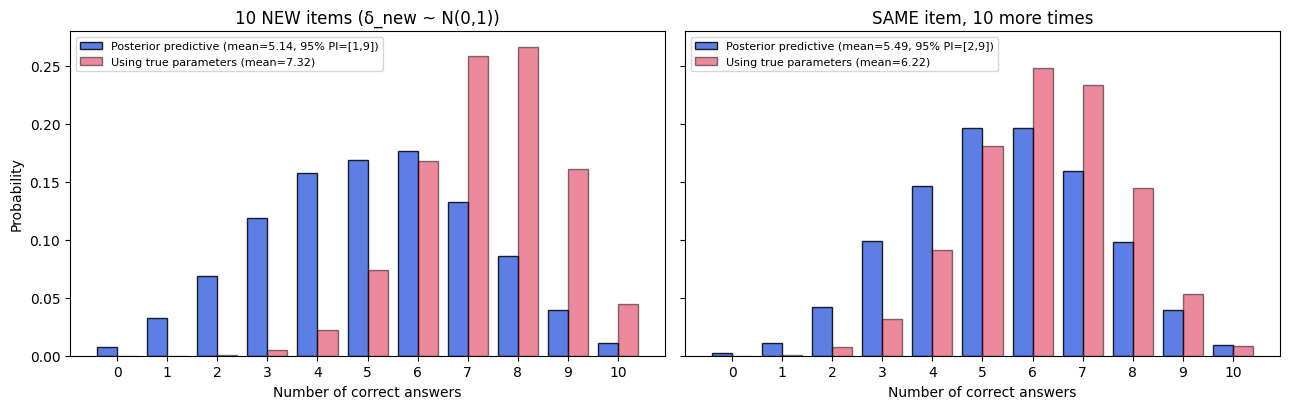

[NEW items]  predictive mean = 5.144, 95% PI = [1. 9.]
[SAME item]  predictive mean = 5.487, 95% PI = [2. 9.]


In [12]:
xs = np.arange(N_NEW + 1)

def pmf_from_samples(s):
    c = np.bincount(s, minlength=N_NEW + 1)
    return c / c.sum()

# reference distributions using the (unknown) true parameters
M = 200_000
d_new_ref = rng.normal(MU_NEW, SIGMA_NEW, size=(M, N_NEW))
k_new_ref = rng.binomial(1, logistic(THETA_TRUE - d_new_ref)).sum(axis=1)
ref_new = pmf_from_samples(k_new_ref)
ref_same = binom.pmf(xs, N_NEW, PHI_TRUE)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, s, ref, title in [
    (axes[0], k_new_s, ref_new, f"{N_NEW} NEW items (δ_new ~ N({MU_NEW:g},{SIGMA_NEW:g}))"),
    (axes[1], k_same_s, ref_same, f"SAME item, {N_NEW} more times"),
]:
    pm = pmf_from_samples(s)
    lo, hi = np.quantile(s, [0.025, 0.975])
    ax.bar(xs - 0.2, pm, width=0.4, color="royalblue", edgecolor="black", alpha=0.85,
           label=f"Posterior predictive (mean={s.mean():.2f}, 95% PI=[{lo:.0f},{hi:.0f}])")
    ax.bar(xs + 0.2, ref, width=0.4, color="crimson", edgecolor="black", alpha=0.5,
           label=f"Using true parameters (mean={np.dot(xs, ref):.2f})")
    ax.set_xticks(xs)
    ax.set_xlabel("Number of correct answers")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper left")
axes[0].set_ylabel("Probability")
plt.tight_layout()
plt.show()

print(f"[NEW items]  predictive mean = {k_new_s.mean():.3f}, 95% PI = {np.quantile(k_new_s, [0.025, 0.975])}")
print(f"[SAME item]  predictive mean = {k_same_s.mean():.3f}, 95% PI = {np.quantile(k_same_s, [0.025, 0.975])}")

### 새 문항 10개 예측에 대한 prior의 영향

5절의 다섯 실험의 사후분포로 새 문항 10개 예측을 다시 계산한다.

experiment                       NEW: mean    95% PI   SAME: mean    95% PI
A: θ~N(0,1),   δ~N(0,1)               5.14     [1,9]         5.49     [2,9]
B: θ~N(0,3),   δ~N(0,1)               5.31    [1,10]         5.48     [2,9]
C: θ~N(2,0.5), δ~N(0,1)               8.00    [5,10]         6.10     [2,9]
D: θ~N(-1,0.5),δ~N(0,1)               3.46     [0,7]         5.10     [2,8]
E: θ~N(0,1),   δ~N(0.7,0.05)          6.49     [3,9]         5.12     [2,9]


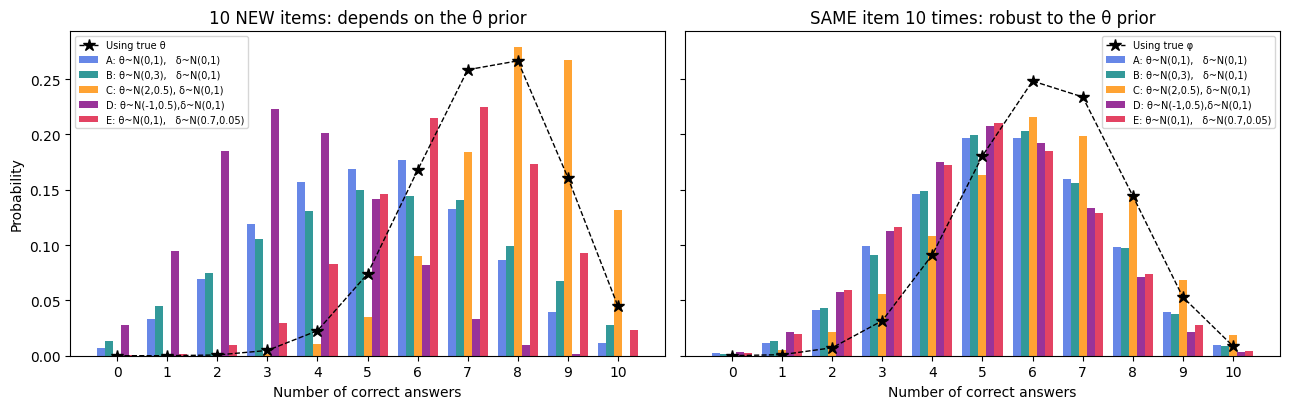

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
w = 0.8 / len(exp_results)
print(f"{'experiment':32s} {'NEW: mean':>9s} {'95% PI':>9s}   {'SAME: mean':>10s} {'95% PI':>9s}")
for i, ((name, *_, d), col) in enumerate(zip(exp_results, colors)):
    kn, ks = d["k_new"].to_numpy().astype(int), d["k_same"].to_numpy().astype(int)
    off = (i - (len(exp_results) - 1) / 2) * w
    axes[0].bar(xs + off, pmf_from_samples(kn), width=w, color=col, alpha=0.8, label=name)
    axes[1].bar(xs + off, pmf_from_samples(ks), width=w, color=col, alpha=0.8, label=name)
    pn, ps_ = np.quantile(kn, [0.025, 0.975]), np.quantile(ks, [0.025, 0.975])
    print(f"{name:32s} {kn.mean():9.2f} {f'[{pn[0]:.0f},{pn[1]:.0f}]':>9s}   {ks.mean():10.2f} {f'[{ps_[0]:.0f},{ps_[1]:.0f}]':>9s}")
axes[0].plot(xs, ref_new, "k*--", markersize=9, linewidth=1, label="Using true θ")
axes[1].plot(xs, ref_same, "k*--", markersize=9, linewidth=1, label="Using true φ")
axes[0].set_title(f"{N_NEW} NEW items: depends on the θ prior")
axes[1].set_title(f"SAME item {N_NEW} times: robust to the θ prior")
for ax in axes:
    ax.set_xticks(xs); ax.set_xlabel("Number of correct answers"); ax.legend(fontsize=7)
axes[0].set_ylabel("Probability")
plt.tight_layout()
plt.show()

## 8. 수치계산 안정성: θ − δ 와 파라메터 drift

δ와 θ를 **둘 다 모르면** likelihood가 $\theta - \delta$ 에만 의존한다. 이 때문에 생기는 수치계산 문제(파라메터 drift)와 그 해결책을 정리한다.

### 8.1 drift란 무엇인가

**직관적 설명.**
능력과 난도를 둘 다 똑같이 $c$ 만큼 올려도 "능력 − 난도"는 그대로이므로 정답확률도, likelihood도 그대로다.
MCMC 샘플러 입장에서는 $(\theta, \delta)$ 평면에 기울기 1인 **끝없이 평평한 골짜기(능선)** 가 있는 것과 같다.
골짜기를 따라 움직여도 목적함수(log posterior)가 변하지 않으면 샘플러를 제자리로 돌려놓는 힘이 없다.
그래서 체인이 골짜기를 따라 한없이 떠내려간다. 이것이 **파라메터 drift** 다.
drift가 일어나도 $\theta - \delta$ 는 멀쩡히 추정되지만, $\theta$ 와 $\delta$ 각각의 값은 의미가 없다.

**수학적 설명.** 모든 $c$ 에 대해

$$
p(y \mid \theta + c,\ \delta + c) = p(y \mid \theta, \delta)
$$

이다 (translation invariance). 회전된 좌표 $\eta = \theta - \delta$ (식별되는 방향), $m = (\theta + \delta)/2$ (식별되지 않는 방향) 를 쓰자.
Jacobian은 1이므로 $d\theta\, d\delta = d\eta\, dm$ 이다. likelihood는 $\eta$ 만의 함수 $L(\eta)$ 이므로, prior가 평평하면(flat) 다음과 같다.

$$
p(\eta, m \mid y) \propto L(\eta) \quad\Rightarrow\quad \int\!\!\int L(\eta)\, d\eta\, dm = \infty
$$

즉 사후분포가 **정규화되지 않는다 (improper posterior)**. $m$ 방향으로는 log posterior의 기울기 $\partial_m \log p = 0$ 이다.
따라서 Hamiltonian Monte Carlo(NUTS)는 그 방향으로 운동량을 잃지 않고 계속 이동한다. Stan에서의 증상은 다음과 같다.

- 체인마다 $\theta, \delta$ 값이 전혀 다른 곳에 있다 → $\hat R \gg 1$, ESS가 매우 작다.
- 궤적이 끝나지 않아 max treedepth(기본 10)에 계속 부딪힌다.
- 실행 길이나 seed를 바꾸면 결과(θ의 평균)가 크게 바뀐다.
- 반면 $\eta = \theta - \delta$ 의 $\hat R$ 과 ESS는 정상이다.

### 8.2 실험: flat prior에서의 drift

prior를 두지 않은(= flat, improper) 모델로 샘플링해 본다.
아래 Stan 모델은 옵션으로 (a) 독립 Normal prior, (b) soft sum-to-zero 항을 켜고 끌 수 있다. 두 옵션을 모두 끄면 flat prior이다.
생성량으로 $\eta$ 와 $m$ 도 계산한다.

14:41:47 - cmdstanpy - INFO - compiling stan file D:\KOS-5101\intro-bayes\irt_1item_1person_ident.stan to exe file D:\KOS-5101\intro-bayes\irt_1item_1person_ident.exe
14:41:59 - cmdstanpy - INFO - compiled model executable: D:\KOS-5101\intro-bayes\irt_1item_1person_ident.exe
14:42:00 - cmdstanpy - INFO - CmdStan start processing
14:42:00 - cmdstanpy - INFO - Chain [1] start processing
14:42:00 - cmdstanpy - INFO - Chain [2] start processing
14:42:00 - cmdstanpy - INFO - Chain [3] start processing
14:42:00 - cmdstanpy - INFO - Chain [4] start processing
14:42:02 - cmdstanpy - INFO - Chain [1] done processing
14:42:02 - cmdstanpy - INFO - Chain [3] done processing
14:42:02 - cmdstanpy - INFO - Chain [4] done processing
14:42:02 - cmdstanpy - INFO - Chain [2] done processing
14:42:02 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 616 iterations at max treedepth (61.6%)
	Chain 2 had 601 iterations at max treedepth (60.1%)
	Chain 3 had 595 iterations at max tr

setting                        E[θ]    sd(θ)  Rhat(θ)   ESS(θ) |   E[η]  sd(η)  Rhat(η)  ESS(η) | treedepth hit  div
flat prior (improper)        252.03  4142.19     2.90        5 |   0.21   0.46     1.00    3317 |         60.8%    0


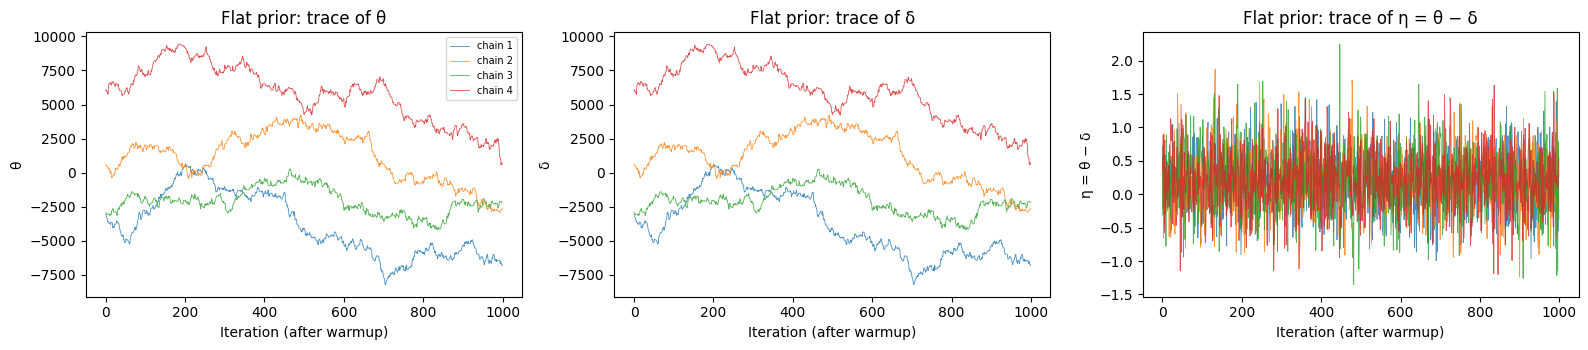

In [14]:
stan_ident = """
data {
  int<lower=1> N;
  array[N] int<lower=0,upper=1> y;
  int<lower=0,upper=1> use_prior;      // 1: independent normal priors on theta and delta
  real<lower=0> sigma_theta;
  real<lower=0> sigma_delta;
  int<lower=0,upper=1> use_soft_sum0;  // 1: soft constraint  theta + delta ~ normal(0, tau)
  real<lower=0> tau;
}
parameters {
  real theta;
  real delta;
}
model {
  if (use_prior == 1) {
    theta ~ normal(0, sigma_theta);
    delta ~ normal(0, sigma_delta);
  }
  if (use_soft_sum0 == 1) {
    target += normal_lpdf(theta + delta | 0, tau);
  }
  y ~ bernoulli_logit(theta - delta);   // flat (improper) prior if both options are off
}
generated quantities {
  real eta = theta - delta;            // identified direction
  real m = (theta + delta) / 2;        // non-identified direction
}
"""
with open("irt_1item_1person_ident.stan", "w", encoding="utf-8") as f:
    f.write(stan_ident)
model_ident = CmdStanModel(stan_file="irt_1item_1person_ident.stan")

MAX_TD = 10
def run_ident(use_prior=0, sigma_theta=1.0, sigma_delta=1.0, use_soft_sum0=0, tau=1.0, seed=SEED):
    return model_ident.sample(
        data={"N": N, "y": y.tolist(), "use_prior": use_prior, "sigma_theta": sigma_theta,
              "sigma_delta": sigma_delta, "use_soft_sum0": use_soft_sum0, "tau": tau},
        chains=4, parallel_chains=4, iter_warmup=1000, iter_sampling=1000,
        seed=seed, show_progress=False, max_treedepth=MAX_TD,
    )

def diagnostics(fit, name):
    s = fit.summary()
    ess_col = "ESS_bulk" if "ESS_bulk" in s.columns else ("N_Eff" if "N_Eff" in s.columns else None)
    mv = fit.method_variables()
    out = {"name": name,
           "treedepth_hit": float(np.mean(mv["treedepth__"] >= MAX_TD)),
           "divergent": int(np.sum(mv["divergent__"]))}
    for v in ["theta", "eta"]:
        out[f"Rhat_{v}"] = float(s.loc[v, "R_hat"]) if "R_hat" in s.columns else np.nan
        out[f"ESS_{v}"] = float(s.loc[v, ess_col]) if ess_col else np.nan
        out[f"mean_{v}"] = float(fit.stan_variable(v).mean())
        out[f"sd_{v}"] = float(fit.stan_variable(v).std())
    return out

def print_diag(rows):
    print(f"{'setting':26s} {'E[θ]':>8s} {'sd(θ)':>8s} {'Rhat(θ)':>8s} {'ESS(θ)':>8s} | {'E[η]':>6s} {'sd(η)':>6s} "
          f"{'Rhat(η)':>8s} {'ESS(η)':>7s} | {'treedepth hit':>13s} {'div':>4s}")
    for r in rows:
        print(f"{r['name']:26s} {r['mean_theta']:8.2f} {r['sd_theta']:8.2f} {r['Rhat_theta']:8.2f} {r['ESS_theta']:8.0f} | "
              f"{r['mean_eta']:6.2f} {r['sd_eta']:6.2f} {r['Rhat_eta']:8.2f} {r['ESS_eta']:7.0f} | "
              f"{100*r['treedepth_hit']:12.1f}% {r['divergent']:4d}")

fit_flat = run_ident(use_prior=0)
print_diag([diagnostics(fit_flat, "flat prior (improper)")])

fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
for ax, v, lab in zip(axes, ["theta", "delta", "eta"], ["θ", "δ", "η = θ − δ"]):
    ch = fit_flat.stan_variable(v).reshape(fit_flat.chains, -1)
    for c in range(ch.shape[0]):
        ax.plot(ch[c], linewidth=0.6, alpha=0.8, label=f"chain {c+1}")
    ax.set_title(f"Flat prior: trace of {lab}")
    ax.set_xlabel("Iteration (after warmup)")
    ax.set_ylabel(lab)
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

**관찰.** flat prior에서는 θ와 δ의 trace가 체인마다 서로 다른 방향으로 떠내려간다. 두 파라메터는 같은 모양으로 함께 움직인다 (θ − δ 가 일정하게 유지되므로).
$\hat R(\theta) \gg 1$ 이고 ESS가 매우 작다. 궤적은 대부분 max treedepth에 부딪힌다.
반면 $\eta$ 의 trace는 정상적으로 섞이고, 사후평균도 $\text{logit}(k/N)$ 근처로 합리적이다. **식별된 양은 멀쩡하고, 식별되지 않은 방향만 drift 한다.**

### 8.3 사전확률 선택으로 drift 방지하기

**직관적 설명.**
평평한 골짜기에 **완만한 그릇 모양의 바닥**을 깔아 주면 샘플러가 골짜기를 따라 멀리 가려 할 때 다시 끌려온다. 적절한 prior가 바로 이 그릇이다.
- $\theta \sim N(0, 1)$ 은 "이 학생의 능력은 기준 집단(평균 0, 표준편차 1)의 척도로 잰다"는 뜻이다. 이 선언이 **척도의 원점과 단위**를 정한다.
- prior 폭이 좁을수록 그릇이 가파르고 drift 범위가 좁다. 너무 넓으면(σ=100) 사후분포는 proper이지만 골짜기가 매우 길다.
  그러면 샘플러가 긴 궤적을 필요로 하고 θ의 값도 사실상 의미가 없다.

**수학적 설명.** $\theta \sim N(\mu_\theta, \sigma_\theta^2)$, $\delta \sim N(\mu_\delta, \sigma_\delta^2)$ 를 회전 좌표로 쓰면 $\theta = m + \eta/2$, $\delta = m - \eta/2$ 이다.
likelihood는 $m$ 과 무관하므로

$$
p(m \mid \eta, y) = p(m \mid \eta) \propto N\!\left(m + \tfrac{\eta}{2} \,\middle|\, \mu_\theta, \sigma_\theta^2\right) N\!\left(m - \tfrac{\eta}{2} \,\middle|\, \mu_\delta, \sigma_\delta^2\right)
$$

두 정규 밀도의 곱이므로 $m \mid \eta$ 는 다음 정규분포를 따른다.

$$
m \mid \eta \sim N\!\left(\frac{\sigma_\delta^2(\mu_\theta - \eta/2) + \sigma_\theta^2(\mu_\delta + \eta/2)}{\sigma_\theta^2 + \sigma_\delta^2},\;\;
\frac{\sigma_\theta^2 \sigma_\delta^2}{\sigma_\theta^2 + \sigma_\delta^2}\right)
$$

- 사후분포가 proper가 되고, drift의 범위는 $\text{sd}(m \mid \eta) = \sigma_\theta\sigma_\delta / \sqrt{\sigma_\theta^2+\sigma_\delta^2}$ 로 제한된다.
- $m$ 방향의 log posterior 기울기 $\partial_m \log p = -\frac{m + \eta/2 - \mu_\theta}{\sigma_\theta^2} - \frac{m - \eta/2 - \mu_\delta}{\sigma_\delta^2}$ 는 0이 아니다. 이것이 샘플러를 되돌리는 **복원력**이다. prior가 좁을수록 복원력이 크다.
- 한쪽 prior만 proper여도 충분하다. 예를 들어 $\sigma_\delta \to \infty$ 이면 $\text{sd}(m\mid\eta) \to \sigma_\theta$ 로 유한하다.
  그래서 다문항·다학생 IRT에서는 흔히 **θ에만** $N(0,1)$ 을 주고 문항 난도에는 넓은 prior를 준다.
- 주의: prior는 수치적 장치이기 전에 **θ의 척도를 정의하는 가정**이다. 5절에서 본 것처럼 그 가정이 θ의 사후평균을 결정한다.

prior 폭을 σ = 1, 10, 100, flat 로 바꿔 가며 비교한다.

14:42:03 - cmdstanpy - INFO - CmdStan start processing
14:42:03 - cmdstanpy - INFO - Chain [1] start processing
14:42:03 - cmdstanpy - INFO - Chain [2] start processing
14:42:03 - cmdstanpy - INFO - Chain [3] start processing
14:42:03 - cmdstanpy - INFO - Chain [4] start processing
14:42:03 - cmdstanpy - INFO - Chain [2] done processing
14:42:03 - cmdstanpy - INFO - Chain [1] done processing
14:42:03 - cmdstanpy - INFO - Chain [4] done processing
14:42:03 - cmdstanpy - INFO - Chain [3] done processing
14:42:03 - cmdstanpy - INFO - CmdStan start processing
14:42:03 - cmdstanpy - INFO - Chain [1] start processing
14:42:03 - cmdstanpy - INFO - Chain [2] start processing
14:42:03 - cmdstanpy - INFO - Chain [3] start processing
14:42:03 - cmdstanpy - INFO - Chain [4] start processing
14:42:03 - cmdstanpy - INFO - Chain [1] done processing
14:42:03 - cmdstanpy - INFO - Chain [2] done processing
14:42:03 - cmdstanpy - INFO - Chain [4] done processing
14:42:03 - cmdstanpy - INFO - Chain [3] do

setting                        E[θ]    sd(θ)  Rhat(θ)   ESS(θ) |   E[η]  sd(η)  Rhat(η)  ESS(η) | treedepth hit  div
θ,δ ~ N(0,1)                   0.11     0.73     1.00     1430 |   0.19   0.43     1.00    4677 |          0.0%    0
θ,δ ~ N(0,10)                  0.25     7.34     1.01      448 |   0.22   0.46     1.00    3124 |          0.0%    0
θ,δ ~ N(0,100)                 3.91    69.77     1.01      410 |   0.20   0.46     1.00    3479 |          0.1%    0
θ ~ N(0,1), δ flat            -0.03     1.01     1.01      859 |   0.22   0.47     1.00    3936 |          0.0%    0
flat prior (improper)        252.03  4142.19     2.90        5 |   0.21   0.46     1.00    3317 |         60.8%    0

theory sd(m | η) = σθσδ/sqrt(σθ²+σδ²):
  θ,δ ~ N(0,1)          : theory    0.707   Stan sd(m) =    0.694
  θ,δ ~ N(0,10)         : theory    7.071   Stan sd(m) =    7.341
  θ,δ ~ N(0,100)        : theory   70.711   Stan sd(m) =   69.775
  θ ~ N(0,1), δ flat    : theory    1.000   Stan sd(m) =    

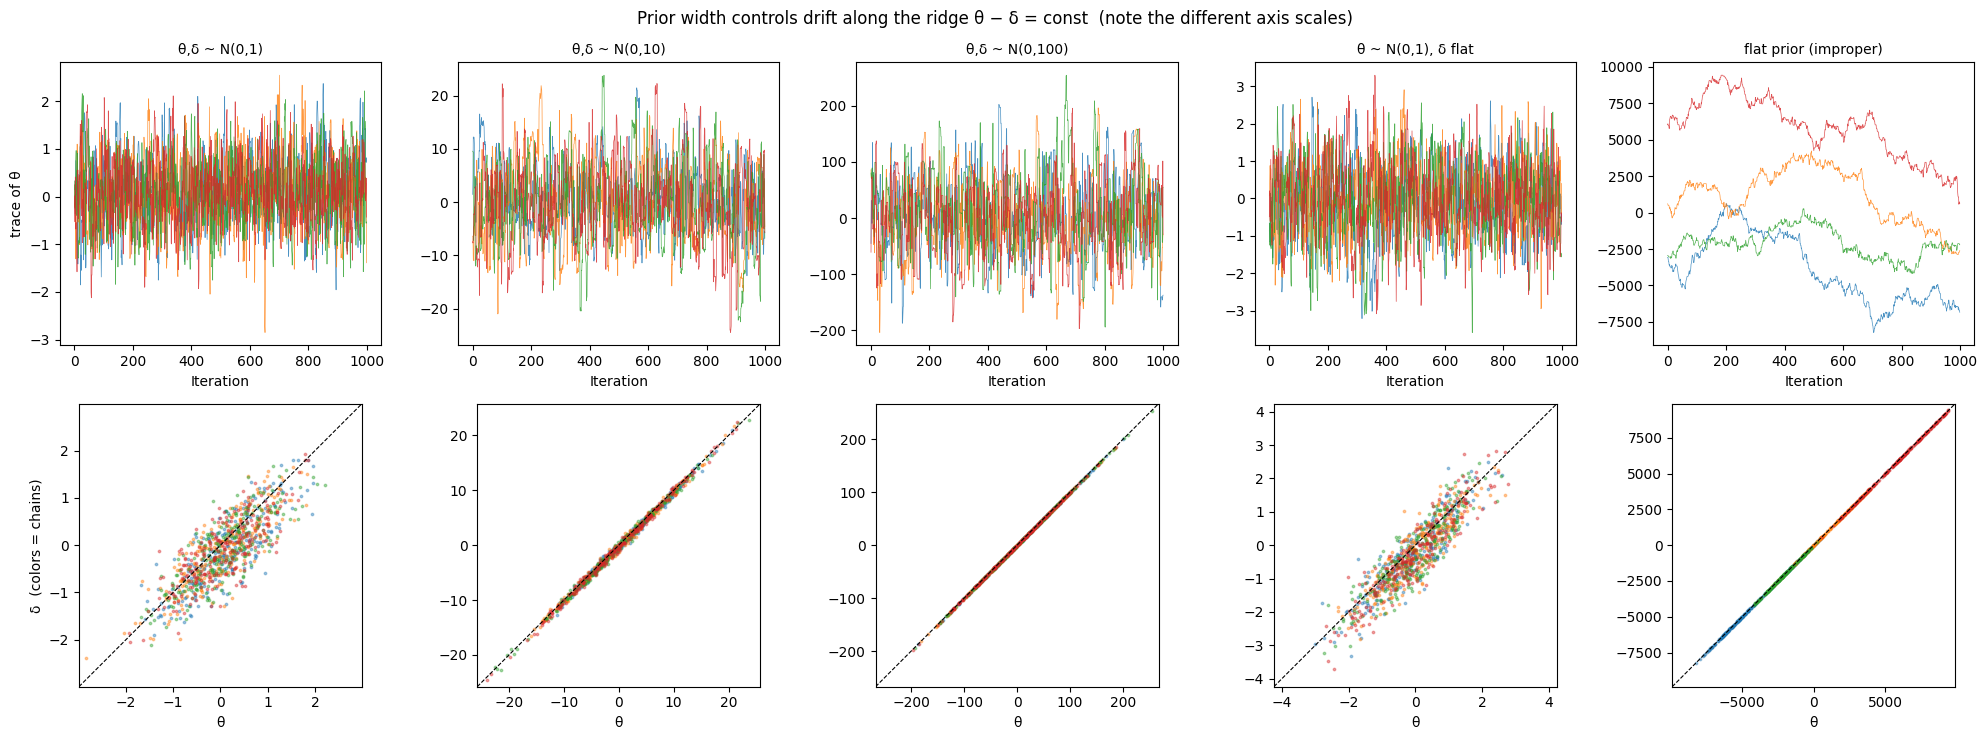

In [15]:
prior_runs = [
    ("θ,δ ~ N(0,1)", dict(use_prior=1, sigma_theta=1.0, sigma_delta=1.0)),
    ("θ,δ ~ N(0,10)", dict(use_prior=1, sigma_theta=10.0, sigma_delta=10.0)),
    ("θ,δ ~ N(0,100)", dict(use_prior=1, sigma_theta=100.0, sigma_delta=100.0)),
    ("θ ~ N(0,1), δ flat", dict(use_prior=1, sigma_theta=1.0, sigma_delta=1e6)),
    ("flat prior (improper)", dict(use_prior=0)),
]
prior_fits = []
for name, kw in prior_runs:
    f = fit_flat if kw.get("use_prior", 0) == 0 else run_ident(**kw)
    prior_fits.append((name, kw, f))

print_diag([diagnostics(f, name) for name, kw, f in prior_fits])
print("\ntheory sd(m | η) = σθσδ/sqrt(σθ²+σδ²):")
for name, kw, f in prior_fits:
    if kw.get("use_prior", 0) == 1:
        st, sdl = kw["sigma_theta"], kw["sigma_delta"]
        print(f"  {name:22s}: theory {st*sdl/np.sqrt(st**2+sdl**2):8.3f}   Stan sd(m) = {f.stan_variable('m').std():8.3f}")

fig, axes = plt.subplots(2, len(prior_fits), figsize=(4.0 * len(prior_fits), 7.5))
for j, (name, kw, f) in enumerate(prior_fits):
    th = f.stan_variable("theta").reshape(f.chains, -1)
    de = f.stan_variable("delta").reshape(f.chains, -1)
    ax = axes[0, j]
    for c in range(th.shape[0]):
        ax.plot(th[c], linewidth=0.5, alpha=0.8)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Iteration")
    if j == 0:
        ax.set_ylabel("trace of θ")
    ax = axes[1, j]
    for c in range(th.shape[0]):
        ax.scatter(th[c, ::4], de[c, ::4], s=3, alpha=0.4)
    lim = max(np.abs(th).max(), np.abs(de).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], color="black", linestyle="--", linewidth=0.8)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.set_xlabel("θ")
    if j == 0:
        ax.set_ylabel("δ  (colors = chains)")
fig.suptitle("Prior width controls drift along the ridge θ − δ = const  (note the different axis scales)", fontsize=12)
plt.tight_layout()
plt.show()

**해석.**
- σ = 1: 네 체인이 같은 영역을 공유하고 $\hat R \approx 1$ 이다. drift가 없다. Stan sd(m)이 이론값 $1/\sqrt2 \approx 0.71$ 과 일치한다.
- σ = 10, 100: 사후분포는 proper이고 결국 수렴한다. 그러나 골짜기 길이가 σ에 비례해 길어진다(축 눈금에 주목). θ의 사후 sd도 σ에 비례해 커진다.
  같은 반복수로 얻는 θ의 ESS가 σ=1일 때의 절반 이하로 줄어든다 (긴 능선을 가로지르려면 더 긴 궤적과 더 많은 반복이 필요하다). 계산 효율이 떨어지고, θ 값 자체의 의미도 사라진다.
  (이 2차원 문제에서는 treedepth 한계에 걸리지 않지만, 파라메터가 많은 IRT 모델에서는 이런 긴 능선이 treedepth 경고와 느린 수렴으로 나타난다.)
- θ ~ N(0,1), δ flat: 한쪽 prior만으로도 drift가 막힌다 (sd(m) ≈ σθ = 1).
- flat: drift. 어떤 반복수로도 수렴하지 않는다 (improper).
- 모든 경우에 $\eta$ 의 사후분포는 거의 같다. prior의 역할은 **식별되지 않는 방향을 고정하는 것**이다.

결론: 두 파라메터를 모두 모를 때는 **척도를 정의하는 적절한 폭의 proper prior**(대표적으로 $\theta \sim N(0,1)$)가 가장 간단하고 해석 가능한 drift 방지책이다.
"무정보적"이라고 아주 넓은 prior를 쓰는 것은 수치적으로 불리하고 해석상 이득도 없다.

### 8.4 drift 방지 방법 정리와 비교

| 방법 | 구현 (Stan) | 무엇을 고정하나 | 1문항·1학생에서 | 다문항·다학생 IRT로의 일반화 |
|---|---|---|---|---|
| 1. **Anchoring (기준점 고정)** | δ를 `data` 로 전달 | 척도 원점 = 보정된 문항의 난도 | 2절 (δ = 0.7 known) | 문항 은행의 보정된 난도, 또는 기준 문항 $\delta_1 = 0$ |
| 2. **Hard sum-to-zero** | `transformed parameters { real delta = -theta; }` | $\theta + \delta = 0$ | 8.5절 | $\sum_j \delta_j = 0$ (Stan 2.36+ `sum_to_zero_vector`), 또는 $\sum_i \theta_i = 0$ |
| 3. **Soft sum-to-zero** | `target += normal_lpdf(theta + delta \| 0, tau);` | $\theta + \delta \approx 0$ (폭 τ) | 아래 실험 | $\sum_j \delta_j \sim N(0, \tau)$ |
| 4. **Proper prior (척도 정의)** | `theta ~ normal(0, 1);` | θ의 원점·단위 = 기준 집단 | 8.3절 | $\theta_i \sim N(0,1)$ (계층모형에서는 $\theta_i \sim N(0,\sigma_\theta)$ + 문항 쪽 제약) |
| 5. **재매개화 (η, m)** | `parameters { real eta; real m; }` 후 θ = m + η/2, δ = m − η/2 | 그 자체로는 아무것도 고정하지 않음. m에 prior가 **반드시** 필요 | 아래 실험 | 상관이 제거된 좌표에서 샘플링 → 효율 향상 |
| 6. 사후 중심화 (post-hoc centering) | 샘플링 후 θ, δ에서 평균을 빼기 | 해석용 원점 | 권장하지 않음 | flat이면 샘플러 자체가 수렴하지 않으므로 사후 처리로 구제할 수 없다 (척도 불변인 양의 요약에만 유효) |

**수학적 공통점.** 비식별 방향은 벡터 $v = (1, 1)$ 방향의 이동(translation)이다.
방법 1~3은 이 방향의 자유도를 제거하거나 제한하는 **제약(constraint)** 이고, 방법 4는 이 방향에 **확률적 복원력**을 주는 prior이다.
방법 5는 좌표축을 $v$ 에 맞춰 돌려서 샘플러가 보는 기하를 단순하게 만든다(식별 자체는 m의 prior가 담당).
어느 방법이든 $\eta = \theta - \delta$ 의 사후분포는 (prior가 η 방향에 거의 영향을 주지 않는 한) 같다. **바뀌는 것은 θ와 δ에 붙는 "원점의 정의"뿐**이다.

아래에서 방법 2, 3, 5를 실행하고 8.2~8.3의 결과와 함께 진단값을 비교한다.

14:42:06 - cmdstanpy - INFO - compiling stan file D:\KOS-5101\intro-bayes\irt_1item_1person_sum0.stan to exe file D:\KOS-5101\intro-bayes\irt_1item_1person_sum0.exe
14:42:18 - cmdstanpy - INFO - compiled model executable: D:\KOS-5101\intro-bayes\irt_1item_1person_sum0.exe
14:42:18 - cmdstanpy - INFO - CmdStan start processing
14:42:18 - cmdstanpy - INFO - Chain [1] start processing
14:42:18 - cmdstanpy - INFO - Chain [2] start processing
14:42:18 - cmdstanpy - INFO - Chain [3] start processing
14:42:18 - cmdstanpy - INFO - Chain [4] start processing
14:42:18 - cmdstanpy - INFO - Chain [4] done processing
14:42:18 - cmdstanpy - INFO - Chain [2] done processing
14:42:18 - cmdstanpy - INFO - Chain [1] done processing
14:42:18 - cmdstanpy - INFO - Chain [3] done processing
14:42:19 - cmdstanpy - INFO - CmdStan start processing
14:42:19 - cmdstanpy - INFO - Chain [1] start processing
14:42:19 - cmdstanpy - INFO - Chain [2] start processing
14:42:19 - cmdstanpy - INFO - Chain [3] start proce

setting                        E[θ]    sd(θ)  Rhat(θ)   ESS(θ) |   E[η]  sd(η)  Rhat(η)  ESS(η) | treedepth hit  div
flat prior (improper)        252.03  4142.19     2.90        5 |   0.21   0.46     1.00    3317 |         60.8%    0
4. prior θ,δ ~ N(0,1)          0.11     0.73     1.00     1430 |   0.19   0.43     1.00    4677 |          0.0%    0
5. rotated (η,m) + N(0,1)      0.09     0.75     1.00     3667 |   0.19   0.43     1.00    3730 |          0.0%    0
3. soft θ+δ ~ N(0,0.1)         0.11     0.24     1.00      707 |   0.21   0.46     1.00     678 |          0.0%    0
2. hard θ+δ = 0                0.11     0.24     1.00     1545 |   0.22   0.48     1.00    1545 |          0.0%    0

posterior corr(θ, δ):  N(0,1) prior = 0.82,  rotated sampler corr(η, m) = -0.01


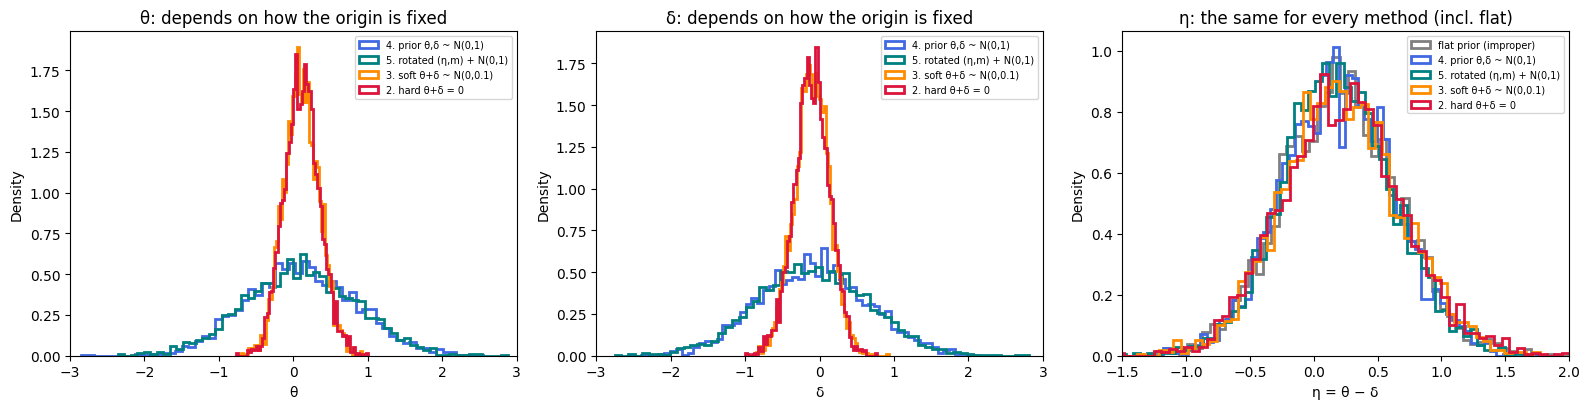

In [16]:
# ---- method 2: hard sum-to-zero  (delta = -theta) ----
stan_sum0 = """
data {
  int<lower=1> N;
  array[N] int<lower=0,upper=1> y;
  real<lower=0> sigma_theta;          // weak prior; the constraint alone already identifies theta
}
parameters {
  real theta;
}
transformed parameters {
  real delta = -theta;                // hard constraint: theta + delta = 0
}
model {
  theta ~ normal(0, sigma_theta);
  y ~ bernoulli_logit(theta - delta); // = bernoulli_logit(2 * theta)
}
generated quantities {
  real eta = theta - delta;
  real m = (theta + delta) / 2;       // always 0
}
"""
with open("irt_1item_1person_sum0.stan", "w", encoding="utf-8") as f:
    f.write(stan_sum0)
model_sum0 = CmdStanModel(stan_file="irt_1item_1person_sum0.stan")
fit_sum0 = model_sum0.sample(data={"N": N, "y": y.tolist(), "sigma_theta": 10.0},
                             chains=4, parallel_chains=4, iter_warmup=1000, iter_sampling=1000,
                             seed=SEED, show_progress=False, max_treedepth=MAX_TD)

# ---- method 3: soft sum-to-zero, no other prior ----
fit_soft = run_ident(use_prior=0, use_soft_sum0=1, tau=0.1)

# ---- method 5: rotated parameterization (eta, m) with the same N(0,1) priors on theta, delta ----
stan_rot = """
data {
  int<lower=1> N;
  array[N] int<lower=0,upper=1> y;
  real<lower=0> sigma_theta;
  real<lower=0> sigma_delta;
}
parameters {
  real eta;                           // identified direction
  real m;                             // non-identified direction
}
transformed parameters {
  real theta = m + eta / 2;
  real delta = m - eta / 2;           // linear map, |Jacobian| = 1 (constant)
}
model {
  theta ~ normal(0, sigma_theta);     // this prior is what identifies m
  delta ~ normal(0, sigma_delta);
  y ~ bernoulli_logit(eta);
}
"""
with open("irt_1item_1person_rotated.stan", "w", encoding="utf-8") as f:
    f.write(stan_rot)
model_rot = CmdStanModel(stan_file="irt_1item_1person_rotated.stan")
fit_rot = model_rot.sample(data={"N": N, "y": y.tolist(), "sigma_theta": 1.0, "sigma_delta": 1.0},
                           chains=4, parallel_chains=4, iter_warmup=1000, iter_sampling=1000,
                           seed=SEED, show_progress=False, max_treedepth=MAX_TD)

method_fits = [
    ("flat prior (improper)", fit_flat),
    ("4. prior θ,δ ~ N(0,1)", prior_fits[0][2]),
    ("5. rotated (η,m) + N(0,1)", fit_rot),
    ("3. soft θ+δ ~ N(0,0.1)", fit_soft),
    ("2. hard θ+δ = 0", fit_sum0),
]
print_diag([diagnostics(f, name) for name, f in method_fits])
print(f"\nposterior corr(θ, δ):  N(0,1) prior = {np.corrcoef(prior_fits[0][2].stan_variable('theta'), prior_fits[0][2].stan_variable('delta'))[0,1]:.2f}"
      f",  rotated sampler corr(η, m) = {np.corrcoef(fit_rot.stan_variable('eta'), fit_rot.stan_variable('m'))[0,1]:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
cols_m = ["gray", "royalblue", "teal", "darkorange", "crimson"]
for (name, f), col in zip(method_fits, cols_m):
    if name.startswith("flat"):
        continue
    axes[0].hist(f.stan_variable("theta"), bins=60, density=True, histtype="step", linewidth=2, color=col, label=name)
    axes[1].hist(f.stan_variable("delta"), bins=60, density=True, histtype="step", linewidth=2, color=col, label=name)
for (name, f), col in zip(method_fits, cols_m):
    axes[2].hist(f.stan_variable("eta"), bins=60, density=True, histtype="step", linewidth=2, color=col, label=name)
axes[0].set_xlabel("θ"); axes[1].set_xlabel("δ"); axes[2].set_xlabel("η = θ − δ")
axes[0].set_title("θ: depends on how the origin is fixed")
axes[1].set_title("δ: depends on how the origin is fixed")
axes[2].set_title("η: the same for every method (incl. flat)")
for ax in axes:
    ax.set_ylabel("Density"); ax.legend(fontsize=7)
axes[0].set_xlim(-3, 3); axes[1].set_xlim(-3, 3); axes[2].set_xlim(-1.5, 2)
plt.tight_layout()
plt.show()

**해석.**
- 방법 2~5는 모두 $\hat R \approx 1$ 이고 treedepth 문제가 없다. drift가 방지된다.
- $\eta$ 의 사후분포는 flat을 포함한 모든 방법에서 거의 같다. **데이터가 결정하는 부분은 방법과 무관하다.**
- $\theta$ 와 $\delta$ 의 분포는 방법마다 다르다. hard 제약에서는 $\theta = \eta/2$ 로 고정되어 분포가 좁다. N(0,1) prior에서는 $m$ 의 불확실성($\text{sd} \approx 0.71$)이 더해져 넓다.
  어느 쪽이 "맞다"가 아니라 **원점을 어떻게 정의했느냐**의 차이다.
- 재매개화(방법 5)는 방법 4와 **같은 사후분포**를 준다. 하지만 샘플러가 보는 좌표 $(\eta, m)$ 는 거의 무상관이다 (θ–δ 상관 ≈ 0.8 에 비해). 그래서 ESS가 더 크다.
  단, m에 prior가 없으면 재매개화만으로는 drift가 그대로 남는다 (m이 flat).

### 8.5 θ + δ = 0 제약은 언제 쓸 수 있는가

**직관적 설명.**
"능력과 난도의 가운데를 원점(0)으로 삼자"는 약속이다. 그러면 정답률이 알려주는 차이 $\eta$ 를 능력과 난도가 반씩 나눠 갖는다: $\theta = \eta/2$, $\delta = -\eta/2$.
1문항·1학생 설계에서는 비식별 방향이 하나뿐이므로 제약 하나로 충분하고, 수치적으로도 가장 깔끔하다 (파라메터가 1개).

**수학적 설명.**
비식별 변환은 $(\theta, \delta) \mapsto (\theta + c, \delta + c)$, 즉 방향 $v = (1, 1)$ 이다.
선형 제약 $a_\theta \theta + a_\delta \delta = b$ 가 이 자유도를 제거하려면 제약이 $v$ 방향 이동에 대해 변해야 한다.

$$
a \cdot v = a_\theta + a_\delta \neq 0
$$

- $\theta + \delta = 0$: $a = (1, 1)$, $a \cdot v = 2 \neq 0$ → **가능.** 해는 $\theta = \eta/2$, $\delta = -\eta/2$ 이다.
- $\theta - \delta = 0$: $a \cdot v = 0$ → **불가능.** 이것은 식별된 양 $\eta$ 를 0으로 강제하는 것이라 데이터와 충돌하고, drift도 막지 못한다.
- $\delta = 0.7$ (anchoring)이나 $\theta = 0$ 도 $a\cdot v \ne 0$ 인 제약이다. 즉 2절의 δ known은 제약의 특수한 경우다.

제약은 척도의 **정의**를 바꾼다. 이 제약 아래에서의 "참값"은 시뮬레이션 척도의 값을 옮긴 것이다.

$$
\theta^{(\text{sum0})}_{\text{true}} = \theta_{\text{true}} - \frac{\theta_{\text{true}} + \delta_{\text{true}}}{2} = \frac{\eta_{\text{true}}}{2} = 0.25,
\qquad \delta^{(\text{sum0})}_{\text{true}} = -0.25
$$

따라서 추정값이 1.2와 0.7로 가지 않는 것은 오류가 아니라 척도 약속의 차이다.
또한 $\mu_\theta = \mu_\delta$, $\sigma_\theta = \sigma_\delta$ 인 대칭 prior(8.3의 σ=1)의 사후평균도 $E[m\mid\eta]=0$, 즉 $E[\theta\mid y] = E[\eta\mid y]/2$ 이다.
따라서 대칭 prior는 **평균적으로는** θ + δ = 0 과 같은 원점을 쓰며, 여기에 불확실성 $\text{sd}(m) = \sigma/\sqrt2$ 를 더한 soft 버전이다.

hard θ+δ=0 : E[θ] = 0.111,  E[η]/2 = 0.111,  E[δ] = -0.111
symmetric N(0,1) priors : E[θ] = 0.106,  E[η]/2 = 0.095
'true' θ on the sum-to-zero scale = θ_true − (θ_true+δ_true)/2 = 0.250
'true' θ on the anchored scale (δ = 0.7 known)  = 1.200


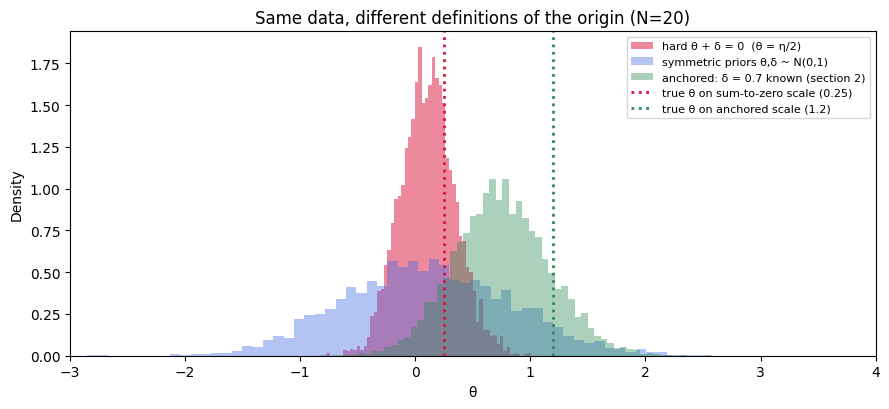

In [17]:
eta_sum0 = fit_sum0.stan_variable("eta")
th_sum0 = fit_sum0.stan_variable("theta")
th_sym = prior_fits[0][2].stan_variable("theta")
print(f"hard θ+δ=0 : E[θ] = {th_sum0.mean():.3f},  E[η]/2 = {eta_sum0.mean()/2:.3f},  E[δ] = {fit_sum0.stan_variable('delta').mean():.3f}")
print(f"symmetric N(0,1) priors : E[θ] = {th_sym.mean():.3f},  E[η]/2 = {prior_fits[0][2].stan_variable('eta').mean()/2:.3f}")
print(f"'true' θ on the sum-to-zero scale = θ_true − (θ_true+δ_true)/2 = {THETA_TRUE - (THETA_TRUE + DELTA_TRUE)/2:.3f}")
print(f"'true' θ on the anchored scale (δ = {DELTA_TRUE} known)  = {THETA_TRUE:.3f}")

g = np.linspace(-3, 4, 800)
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(th_sum0, bins=60, density=True, alpha=0.5, color="crimson", label="hard θ + δ = 0  (θ = η/2)")
ax.hist(th_sym, bins=60, density=True, alpha=0.4, color="royalblue", label="symmetric priors θ,δ ~ N(0,1)")
ax.hist(known_cases[0][3]["theta"], bins=60, density=True, alpha=0.4, color="seagreen",
        label=f"anchored: δ = {DELTA_TRUE} known (section 2)")
ax.axvline(THETA_TRUE - (THETA_TRUE + DELTA_TRUE) / 2, color="crimson", linestyle=":", linewidth=2,
           label="true θ on sum-to-zero scale (0.25)")
ax.axvline(THETA_TRUE, color="seagreen", linestyle=":", linewidth=2, label=f"true θ on anchored scale ({THETA_TRUE})")
ax.set_xlim(-3, 4)
ax.set_xlabel("θ")
ax.set_ylabel("Density")
ax.set_title("Same data, different definitions of the origin (N=20)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**θ + δ = 0 을 쓸 수 있는 경우**

1. 비식별성이 **평행이동 하나뿐**인 모델일 때. 1PL(Rasch) 모델이 그렇다: $\text{logit}\,P(y_{ij}=1) = \theta_i - \delta_j$.
2. 외부 기준(보정된 문항 난도, 기준 집단의 능력 분포)이 **없을 때**. 이때 원점을 정하는 하나의 약속으로 쓸 수 있다.
3. 1문항·1학생에서는 제약이 정확히 하나 필요하므로 $\theta + \delta = 0$ 이 딱 맞는다. 결과 해석은 "θ는 능력과 난도의 중간점을 기준으로 잰 값"이다.
4. 다문항·다학생으로 일반화하면 $\sum_i \theta_i + \sum_j \delta_j = 0$ 도 수학적으로는 유효하다 ($a\cdot v = I + J \neq 0$).
   그러나 원점이 학생 구성과 문항 구성에 함께 의존해 해석이 불편하다. 그래서 실무에서는 보통 $\sum_j \delta_j = 0$ (문항 중심화) 또는 $\theta_i \sim N(0,1)$ 을 쓴다.

**쓰면 안 되거나 부적절한 경우**

- **δ를 이미 아는 경우 (2절).** 원점이 이미 정해져 있다. 여기에 θ + δ = 0 을 더하면 제약이 둘이 된다 ($\delta = 0.7 \Rightarrow \theta = -0.7$).
  그러면 데이터가 말하는 $\eta \approx 0.2$ 와 충돌해 모델이 잘못 지정된다 (over-constrained).
- **모든 쌍에 대해 $\theta_i + \delta_j = 0$ 을 거는 것.** 제약이 비식별 자유도(1개)보다 훨씬 많아 데이터와 모순된다.
- **2PL 이상의 모델** ($\text{logit} = \alpha_j(\theta_i - \delta_j)$). 척도의 단위(scale)에 대한 비식별성이 추가로 있다: $\theta \to s\theta,\ \delta \to s\delta,\ \alpha \to \alpha/s$.
  θ + δ = 0 하나로는 부족하고, $\text{sd}(\theta)=1$ 이나 $\prod_j \alpha_j = 1$ 같은 두 번째 제약이 필요하다.
- **서로 다른 시험·집단의 θ를 비교해야 할 때.** 원점이 데이터 구성에 따라 달라지므로 척도 연결(linking/equating) 없이는 비교할 수 없다.

**구현상의 주의:** 제약은 `transformed parameters { real delta = -theta; }` 처럼 **재매개화로 정확히** 구현한다.
`target += normal_lpdf(theta + delta | 0, 1e-6)` 처럼 매우 좁은 soft 제약으로 흉내 내면 사후분포가 극단적으로 얇은 능선이 된다.
그러면 step size가 작아지고 샘플링이 비효율적이 된다 (stiff geometry). soft 제약은 τ를 적당한 크기(예: 0.1~1)로 둘 때만 쓴다.

## 9. 결론 및 논의

- **모델.** $\phi = \text{logistic}(\theta - \delta)$ 인 1PL(Rasch) 모델에서 1문항·1학생 반복 데이터는 성공 수 $k$ 를 통해 $\eta = \theta - \delta$ 에 대한 정보만 제공한다.
- **θ의 사후확률.** θ의 사후분포는 prior에서 조금만 업데이트된다. 사후분포의 위치와 폭은 θ prior와 δ prior의 **상대적인 폭과 위치**가 결정한다.
  강한 잘못된 prior(C, D)는 데이터로 교정되지 않는다. N을 늘려도 θ의 사후 sd는 0으로 가지 않는다 (6절).
- **θ가 식별되려면** δ에 대한 외부 정보가 필요하다. 예: 사전 보정된 문항(E), 또는 여러 학생·여러 문항 데이터와 척도 고정 조건(다문항 IRT).
- **예측.**
  - 같은 문항을 다시 푸는 경우의 예측은 η에만 의존하므로 prior에 강건하다.
  - **새로운 문항 10개**를 푸는 경우의 예측은 θ 자체의 사후분포와 새 문항 난도 분포에 의존한다. 따라서 θ prior의 선택이 예측 결과(평균 정답 수)를 직접 바꾼다.
    기준 prior(A)에서의 예측 평균과 95% 예측구간은 7절의 출력으로 보고한다. 예측구간이 넓은 것은 θ의 불확실성과 새 문항 난도의 변동이 함께 반영되었기 때문이다.
- **δ를 아는 경우 (2절).** δ가 척도의 기준점이 되어 θ가 식별된다. 사후 sd는 $\approx 1/\sqrt{N\phi(1-\phi)}$ 로 줄고 사후평균은 참값으로 수렴한다.
- **수치계산 안정성 (8절).** θ와 δ를 모두 모르면 likelihood가 $\theta-\delta$ 방향으로만 정보를 준다. flat prior에서는 사후분포가 improper가 되어 파라메터가 drift 한다.
  해결책은 식별되지 않는 방향 $m = (\theta+\delta)/2$ 를 고정하는 것이다: anchoring, hard/soft sum-to-zero, 척도를 정의하는 proper prior(예: θ ~ N(0,1)), 그리고 효율을 위한 (η, m) 재매개화.
  θ + δ = 0 은 1PL에서 원점을 정하는 유효한 제약이지만 δ를 이미 알거나 2PL 이상인 경우에는 부적절하다.